In [349]:
# %pip install pandas pyarrow scikit-learn pymorphy3 joblib

In [350]:
# del df 

In [351]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib
import json

import re
from pymorphy3 import MorphAnalyzer
import emoji

from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# импортируем трансформеры
import transformers
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torchutils as tu
from torchmetrics.classification import BinaryAccuracy

import mplcyberpunk
plt.style.use('cyberpunk')

import os

import pickle

from tqdm.auto import tqdm

# Инициализируем tqdm для pandas
tqdm.pandas()

import copy
from time import time

from collections import Counter
# date, content, label

In [352]:
# Загрузка данных
df = pd.read_feather('data/tg_channels.feather')

print(df.head())

                               url                      date  \
0  https://t.me/s/russianmoda/5961 2023-09-17 17:09:06+00:00   
1  https://t.me/s/russianmoda/5957 2023-09-17 12:09:06+00:00   
2  https://t.me/s/russianmoda/5951 2023-09-17 06:09:06+00:00   
3  https://t.me/s/russianmoda/5939 2023-09-16 17:09:06+00:00   
4  https://t.me/s/russianmoda/5935 2023-09-16 12:09:06+00:00   

                                             content label  
0  Широкие бедра всегда считались роскошью и прид...  мода  
1  Не знаю как у вас, но у меня ни одна осень не ...  мода  
2  Осенью настроение немножко ухудшается. Этому с...  мода  
3  Кардиган очень коварен в стилизации, поэтому е...  мода  
4  Трикотажные костюмы часто ассоциируются с брюк...  мода  


In [353]:
df.loc[30]


url                          https://t.me/s/russianmoda/5839
date                               2023-09-10 12:24:06+00:00
content    Тренчкоты могут быть не только в классическом ...
label                                                   мода
Name: 30, dtype: object

In [354]:
df.shape

(2900, 4)

In [355]:
df['label'].value_counts(normalize=True)

label
технологии    0.206897
крипта        0.206897
финансы       0.206897
мода          0.206207
спорт         0.173103
Name: proportion, dtype: float64

In [356]:
df.describe()

,url,date,content,label
count,2900,2900,2852,2900
unique,2900,NaN,2779,5
top,https://t.me/s/russianmoda/5961,NaN,🔝30 самых популярных монет на прошедшей неделе...,технологии
freq,1,NaN,3,600
mean,NaN,2023-08-14 12:46:32.431379200+00:00,NaN,NaN
min,NaN,2022-11-21 15:46:54+00:00,NaN,NaN
25%,NaN,2023-07-28 15:07:17.249999872+00:00,NaN,NaN
50%,NaN,2023-09-02 12:25:26.500000+00:00,NaN,NaN
75%,NaN,2023-09-13 16:31:23.750000128+00:00,NaN,NaN
max,NaN,2023-09-17 20:17:38+00:00,NaN,NaN


In [357]:
df['content'][1000]

'Евгений Рылов не собирается прогибаться под требования МОК: олимпийский чемпион заявил, что откажется подписывать декларации для участия в ОИ."В МОК могут выдвинуть условия подписать декларацию, если мне такое предложат, я точно откажусь", - сказал пловец.Достойное решение 👏🏻'

In [358]:
morph = MorphAnalyzer()

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

def clean_text_v2(text):
    # 1. Удаляем ссылки (t.me, http, https)
    text = re.sub(r'https?://\S+|www\.\S+|t\.me/\S+', ' ', text)

    text = re.sub(r'@\S+', ' ', text)
    
    # 2. Удаляем ВСЁ, кроме букв (русских и английских) и пробелов
    # Это очистит эмодзи (👏🏻, 🏆), пунктуацию и цифры
    text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
    
    # 3. Приводим к нижнему регистру и убираем лишние пробелы
    text = text.lower().strip()
    
    # 4. Лемматизация (приведение к начальной форме)
    # Разбиваем текст на слова, лемматизируем и оставляем слова длиннее 2 символов
    # Лемматизация + удаление стоп-слов + фильтрация по длине
    tokens = [
        morph.parse(word)[0].normal_form 
        for word in text.split() 
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(tokens)

# Проверка на вашем примере:
example = df['content'][100]
print(f"Результат очистки:\n{clean_text_v2(example)}")

Результат очистки:
самый стильный образ пиджак созадть сочетать платье комбинация комбинация считаться база гардероб помимо пиджак быть отлично смотреться рубашка свитер love republic gate namelazz


[nltk_data] Downloading package stopwords to /home/andre/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [359]:
df.isna().mean()

url        0.000000
date       0.000000
content    0.016552
label      0.000000
dtype: float64

In [360]:
cleaned_content = df['content'].fillna("").apply(clean_text_v2)
empty_after_clean = cleaned_content.isin(["", None])
print(f"Станут пустыми после очистки: {empty_after_clean.sum()}")

Станут пустыми после очистки: 49


если контента нет, то эти строки не информативны так как невозможно на основании пустоты предсказать тему

In [361]:
df = df.dropna(subset=['content'])

In [362]:
df.isna().mean()

url        0.0
date       0.0
content    0.0
label      0.0
dtype: float64

### BaseLine на LogisticRegression

In [363]:
df['label'].value_counts(normalize=True)

label
мода          0.208976
технологии    0.206522
финансы       0.204418
крипта        0.204418
спорт         0.175666
Name: proportion, dtype: float64

In [364]:
print("Начинаю очистку датасета...")
df['cleaned_content'] = df['content'].apply(clean_text_v2)
print("Очистка завершена!")

Начинаю очистку датасета...
Очистка завершена!


In [365]:
print(df['content'][101])
print(df['cleaned_content'][101])

Сейчас актуальны и укороченные, и удлиненные модели пиджаков. Конечно же, помним и про классику. У брендов ниже представлены самые необычные варианты, из которых вы точно выберете свой идеальный пиджак!SHI SHISTUDIO 29Nude StoryLichi
актуальный укоротить удлинённый модель пиджак помнить классика бренд ниже представить самый необычный вариант который точно выбрать свой идеальный пиджак shi shistudio nude storylichi


In [366]:
mapping = {'мода': 0, 
           'технологии': 1, 
           'финансы': 2, 
           'крипта': 3, 
           'спорт': 4}
df['label_num'] = df['label'].map(mapping)

In [367]:
df_lr = df[df['cleaned_content'].str.split().str.len() >= 3].copy()

In [368]:
df_lr

,url,date,content,label,cleaned_content,label_num
0,https://t.me/s/russianmoda/5961,2023-09-17 17:09:06+00:00,Широкие бедра всегда считались роскошью и прид...,мода,широкий бедро считаться роскошь придавать похо...,0
1,https://t.me/s/russianmoda/5957,2023-09-17 12:09:06+00:00,"Не знаю как у вас, но у меня ни одна осень не ...",мода,знать один осень обходиться кожаный куртка сез...,0
2,https://t.me/s/russianmoda/5951,2023-09-17 06:09:06+00:00,Осенью настроение немножко ухудшается. Этому с...,мода,осень настроение немножко ухудшаться этот спос...,0
3,https://t.me/s/russianmoda/5939,2023-09-16 17:09:06+00:00,"Кардиган очень коварен в стилизации, поэтому е...",мода,кардиган очень коварный стилизация поэтому нез...,0
4,https://t.me/s/russianmoda/5935,2023-09-16 12:09:06+00:00,Трикотажные костюмы часто ассоциируются с брюк...,мода,трикотажный костюм часто ассоциироваться брюки...,0
...,...,...,...,...,...,...
2895,https://t.me/s/crypto_dancing/848,2023-06-29 17:30:58+00:00,Mastercard планирует создать магазин для блокч...,крипта,mastercard планировать создать магазин блокчей...,3
2896,https://t.me/s/crypto_dancing/847,2023-06-29 13:01:21+00:00,Hang Seng Investment Management рассматривает ...,крипта,hang seng investment management рассматривать ...,3
2897,https://t.me/s/crypto_dancing/846,2023-06-28 16:31:03+00:00,Аналитик Bloomberg оценил шансы BlackRock на з...,крипта,аналитик bloomberg оценить шанс blackrock запу...,3
2898,https://t.me/s/crypto_dancing/845,2023-06-28 12:00:47+00:00,Профессия блокчейн-разработчика✏️ ♾ Блокчейн-п...,крипта,профессия блокчейн разработчик блокчейн проект...,3


In [369]:
X_train, X_valid, y_train, y_valid = train_test_split(df_lr['cleaned_content'], df_lr['label_num'], test_size=0.25, random_state=42, stratify=df_lr['label_num'])
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.2, random_state=42, stratify=y_valid)
print(f"Обучение (Train): {len(X_train)} строк")
print(f"Валидация (Val):   {len(X_valid)} строк")
print(f"Тест (Test):       {len(X_test)} строк")

Обучение (Train): 2135 строк
Валидация (Val):   569 строк
Тест (Test):       143 строк


In [370]:
X_train_lr = X_train.copy()
X_valid_lr = X_valid.copy()
X_test_lr = X_test.copy()
y_train_lr = y_train.copy()
y_valid_lr = y_valid.copy()
y_test_lr = y_test.copy()

In [371]:
# print("Начинаю очистку датасета...")
# X_train_lr = X_train.apply(clean_text_v2)
# X_valid_lr = X_valid.apply(clean_text_v2)
# X_test_lr = X_test.apply(clean_text_v2)


# # Оставляем только те строки, где есть хотя бы 3 слова (не пустые)
# mask = X_train_lr.str.split().str.len() >= 3
# maskv = X_valid_lr.str.split().str.len() >= 3
# maskt = X_test_lr.str.split().str.len() >= 3

# X_train_lr, y_train_lr = X_train_lr[mask], y_train[mask]
# X_valid_lr, y_valid_lr = X_valid_lr[maskv], y_valid[maskv]
# X_test_lr, y_test_lr = X_test_lr[maskt], y_test[maskt]


# print("Очистка завершена!")

In [372]:
print(X_train_lr)

828     разыгрывать парный билет финал pari кубок росс...
1777    европейский авиакомпания начинать заранее обка...
198     красивый кайя гербер новый кампейн valentino ф...
645     это случиться рпл найтись клуб топ который сог...
2784    стейблкоина usdc появиться новый блокчейн джер...
                              ...                        
2426    топ проект рост сообщество основный социальный...
1572    россия начать блокировать википедия первый нап...
988     мокнуть точно оценить предложение лидер справе...
661     давать передохнуть секунда роналда назвать сам...
1092    это новак джокович человек который нагонять ст...
Name: cleaned_content, Length: 2135, dtype: object


In [373]:
print(y_train_lr)

828     4
1777    2
198     0
645     4
2784    3
       ..
2426    3
1572    1
988     4
661     4
1092    4
Name: label_num, Length: 2135, dtype: int64


In [374]:
from collections import Counter

# Собираем все слова из тренировочной выборки
all_words = ' '.join(X_train_lr).split()
word_counts = Counter(all_words)

print(f"Всего уникальных слов: {len(word_counts)}")

# Смотрим, сколько слов встречаются хотя бы 2 или 3 раза
min_freq = 3
words_above_min = [w for w, c in word_counts.items() if c >= min_freq]
print(f"Слов с частотой >= {min_freq}: {len(words_above_min)}")

Всего уникальных слов: 18315
Слов с частотой >= 3: 6679


In [375]:
tfidf = TfidfVectorizer(max_features=6655, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_lr)
X_valid_tfidf = tfidf.transform(X_valid_lr)
X_test_tfidf = tfidf.transform(X_test_lr)

In [376]:
model_logreg = LogisticRegression(C=15, max_iter=1000, random_state=42)
model_logreg.fit(X_train_tfidf, y_train_lr)

# Предсказываем на валидации
y_pred_val = model_logreg.predict(X_valid_tfidf)

# Смотрим результат
print(f"Accuracy на валидации: {accuracy_score(y_valid_lr, y_pred_val):.4f}")
print(f"F1 macro: {f1_score(y_valid_lr, y_pred_val, average='macro'):.4f}")
print("\nОтчет по классам:")
print(classification_report(y_valid_lr, y_pred_val))
accuracy_logreg_valid = accuracy_score(y_valid_lr, y_pred_val)
macro_f1_logreg_valid = f1_score(y_valid_lr, y_pred_val, average='macro')
macro_f1_weighted_valid = f1_score(y_valid_lr, y_pred_val, average='weighted')

Accuracy на валидации: 0.9332
F1 macro: 0.9342

Отчет по классам:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       119
           1       0.84      0.95      0.89       117
           2       0.95      0.90      0.92       117
           3       0.98      0.94      0.96       116
           4       0.95      0.94      0.94       100

    accuracy                           0.93       569
   macro avg       0.94      0.93      0.93       569
weighted avg       0.94      0.93      0.93       569



In [377]:
# 1. Новое сообщение для проверки
new_text = "мячи для футбола стали лучше"

target_names = {v: k for k, v in mapping.items()}

# 2. Преобразование текста в TF-IDF векторы
# ВАЖНО: используем transform, а не fit_transform
new_text_tfidf = tfidf.transform([new_text])

# 3. Предсказание модели
prediction = model_logreg.predict(new_text_tfidf)

# 4. Получение вероятностей (если нужно увидеть уверенность)
probabilities = model_logreg.predict_proba(new_text_tfidf)

# Вывод результата
print(f"Текст: {new_text}")
print(f"Предсказанный класс: {target_names[prediction[0]]}")
print(f"Уверенность: {probabilities.max():.2%}")

Текст: мячи для футбола стали лучше
Предсказанный класс: спорт
Уверенность: 27.71%


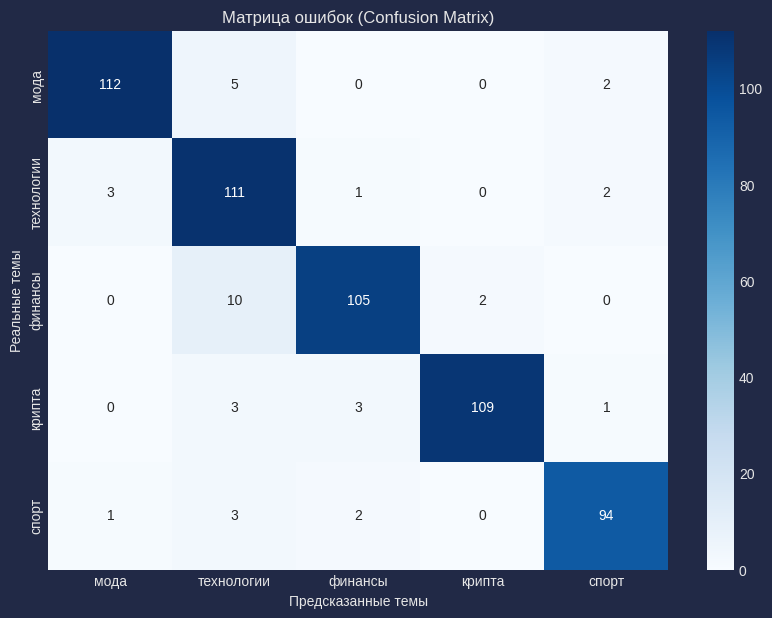

In [378]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_valid_lr, y_pred_val)

# Используем названия тем из вашего маппинга для подписей осей
# Убедитесь, что порядок в списке совпадает с цифрами 0, 1, 2, 3, 4 в mapping
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные темы')
plt.xlabel('Предсказанные темы')
plt.show()

In [379]:
y_pred_test = model_logreg.predict(X_test_tfidf)

# Смотрим результат
print(f"Accuracy на тесте: {accuracy_score(y_test_lr, y_pred_test):.4f}")
print(f"F1 macro: {f1_score(y_test_lr, y_pred_test, average='macro'):.4f}")
print("\nОтчет по классам:")

print(classification_report(y_test_lr, y_pred_test))
accuracy_logreg_test = accuracy_score(y_test_lr, y_pred_test)
macro_f1_logreg_test = f1_score(y_test_lr, y_pred_test, average='macro')
macro_f1_weighted_test = f1_score(y_test_lr, y_pred_test, average='weighted')

Accuracy на тесте: 0.9231
F1 macro: 0.9275

Отчет по классам:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        30
           1       0.76      0.93      0.84        30
           2       1.00      0.90      0.95        29
           3       1.00      0.86      0.93        29
           4       1.00      0.96      0.98        25

    accuracy                           0.92       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.92      0.93       143



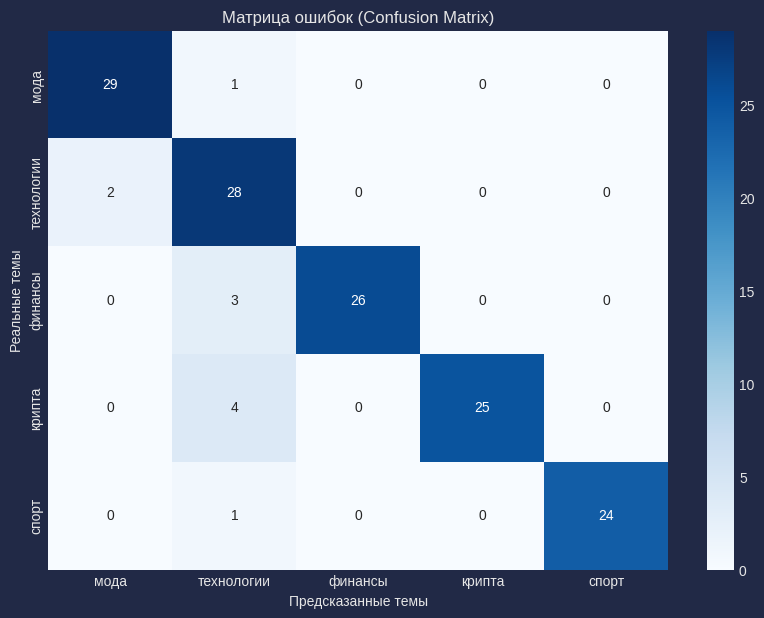

In [380]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test_lr, y_pred_test)

# Используем названия тем из вашего маппинга для подписей осей
# Убедитесь, что порядок в списке совпадает с цифрами 0, 1, 2, 3, 4 в mapping
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные темы')
plt.xlabel('Предсказанные темы')
plt.show()

In [381]:
result_all = {}
result_all['logreg_valid'] = {
    'accuracy': accuracy_logreg_valid,
    'f1_macro': macro_f1_logreg_valid,
    'f1_weighted': macro_f1_weighted_valid
}
result_all['logreg_test'] = {
    'accuracy': accuracy_logreg_test,
    'f1_macro': macro_f1_logreg_test,
    'f1_weighted': macro_f1_weighted_test
}

In [382]:
result_all

{'logreg_valid': {'accuracy': 0.9332161687170475,
  'f1_macro': 0.9341772853997663,
  'f1_weighted': 0.9338830246171204},
 'logreg_test': {'accuracy': 0.9230769230769231,
  'f1_macro': 0.9275225751537401,
  'f1_weighted': 0.9255877385874621}}

сохраняем модель

In [383]:
import joblib

# Создаем обратный маппинг для предсказаний
inverse_mapping = {v: k for k, v in mapping.items()}

save_path = 'models/log_reg_tg'
os.makedirs(save_path, exist_ok=True)

# Сохраняем его тоже
joblib.dump(inverse_mapping, os.path.join(save_path, 'class_mapping.pkl'))

# Сохраняем саму модель
joblib.dump(model_logreg, os.path.join(save_path,'model_logreg.pkl'))

# TF-IDF векторизатор, 
joblib.dump(tfidf, os.path.join(save_path,'tfidf_vectorizer.pkl'))

print("Модель успешно сохранена!")


Модель успешно сохранена!


In [384]:
# from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)
# rf.fit(X_train_tfidf, y_train)

In [385]:
# y_pred_valid_rf =rf.predict(X_valid_tfidf)
# print(f"ИТОГОВАЯ Accuracy на ТЕСТЕ: {accuracy_score(y_valid, y_pred_valid_rf):.4f}")

In [386]:
# y_pred_test_rf = rf.predict(X_test_tfidf)
# print(f"ИТОГОВАЯ Accuracy на ТЕСТЕ: {accuracy_score(y_test, y_pred_test_rf):.4f}")

Отличный показатель логистической регрессии на baseline

### LSTM

готовим данные

In [387]:
# def clean_lstm(text):
#     # 1. Базовая очистка
#     text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
#     text = re.sub(r'@\S+', ' ', text)
#     text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
#     text = text.lower().strip()

#     tokens = []
#     for word in text.split():
#         # Лемматизация
#         normal_form = morph.parse(word)[0].normal_form
        
#         # Убираем стоп-слова и короткие токены
#         if normal_form not in stop_words and len(normal_form) > 2:
#             tokens.append(normal_form)

#     return " ".join(tokens) 

In [388]:
# def clean_lstm(text):
#     # 1. Удаляем ссылки и упоминания (это шум)
#     text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
#     text = re.sub(r'@\S+', ' ', text)
    
#     # 2. Оставляем только буквы и базовую пунктуацию (опционально)
#     # Убираем цифры и спецсимволы, но оставляем пробелы
#     text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
    
#     # 3. Приводим к нижнему регистру и убираем лишние пробелы
#     text = text.lower().strip()
    
#     # 4. Токенизация без жесткой фильтрации
#     tokens = text.split()
    
#     # РЕКОМЕНДАЦИЯ: 
#     # - Не удаляй стоп-слова (они важны для структуры предложения в LSTM)
#     # - Не используй лемматизацию (лучше оставить слова как есть, чтобы модель видела падежи/числа)
#     # - Ограничимся только фильтром совсем короткого мусора (1-2 символа, если это не предлоги)
    
#     clean_tokens = [word for word in tokens if len(word) > 1]
    
#     return " ".join(clean_tokens)

In [389]:
def clean_lstm(text):
    text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
    text = re.sub(r'@\S+', ' ', text)
    text = re.sub(r'[^а-яА-Яa-zA-Z\s]', ' ', text)
    text = text.lower().strip()
    
    # Лемматизируем, но НЕ выкидываем стоп-слова
    tokens = [morph.parse(word)[0].normal_form for word in text.split()]
    # Убираем только совсем мусор (одиночные буквы, кроме 'я', 'и', 'в' и т.д., если хочешь)
    tokens = [t for t in tokens if len(t) > 1 or t in ['я', 'и', 'в', 'не', 'на']]
    
    return " ".join(tokens)

In [390]:
# import re

# def clean_lstm(t):
#     if not isinstance(t, str):
#         return ""

#     # удалить HTML
#     t = re.sub(r"<.*?>", " ", t)

#     # удалить ссылки
#     t = re.sub(r"http\S+|www\.\S+", " ", t)

#     # удалить юзернеймы
#     t = re.sub(r"@\w+", " ", t)

#     # удалить timestamps
#     t = re.sub(r"\b\d{1,2}:\d{2}\b", " ", t)

#     # удалить даты (простые форматы)
#     t = re.sub(r"\b\d{4}-\d{2}-\d{2}\b", " ", t)

#     # удалить маркдауны
#     t = re.sub(r"[*_`~]", " ", t)

#     # обозначения вложений
#     t = re.sub(r"\[(photo|video|voice|sticker|gif|file)\]", " ", t)

#     # оставить только буквы/цифры/точки/запятые
#     t = re.sub(r"[^a-zA-Zа-яА-Я]", " ", t)

#     # схлопнуть пробелы
#     t = re.sub(r"\s+", " ", t).strip()

#     t = t.lower()
    
#     tokens = []
#     for word in t.split():
#         if word.startswith('#'):  # хэштеги как есть
#             tokens.append(word)
#             continue
        
#         try:
#             lemma = morph.parse(word)[0].normal_form
#             if len(lemma) >= 2:
#                 tokens.append(lemma)
#         except:
#             continue
    
#     return " ".join(tokens)


In [391]:
# def clean_lstm(text):
    
#     morph = MorphAnalyzer()
    
#     # Удаляем шум
#     text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
#     text = re.sub(r'@\w+', ' ', text)
    
#     # Оставляем: буквы, цифры, хэштеги, эмодзи, базовую пунктуацию
#     # \U0001F300-\U0001F9FF — диапазон популярных эмодзи
#     text = re.sub(r'[^\w\s#а-яА-ЯA-Za-z0-9!?.,:;()\-\U0001F300-\U0001F9FF]', ' ', text)
    
#     text = text.lower()
    
#     tokens = []
#     for word in text.split():
#         if word.startswith('#'):  # хэштеги как есть
#             tokens.append(word)
#             continue
        
#         try:
#             lemma = morph.parse(word)[0].normal_form
#             if len(lemma) >= 2:
#                 tokens.append(lemma)
#         except:
#             continue
    
#     return " ".join(tokens)

In [392]:
# def clean_lstm(text):
#     # Удаляем только явный шум
#     text = re.sub(r'https?://\S+|t\.me/\S+', ' ', text)
#     text = re.sub(r'@\w+', ' ', text)
    
#     # ОСТАВЛЯЕМ ВСЁ: цифры, знаки, эмодзи, хэштеги
#     text = re.sub(r'[^\w\s#а-яА-ЯA-Za-z0-9]', ' ', text)
    
#     text = text.lower()
    
#     # Лемматизация
#     tokens = []
#     for word in text.split():
#         if word.startswith('#'):
#             tokens.append(word)
#             continue
#         try:
#             lemma = morph.parse(word)[0].normal_form
#             if len(lemma) >= 2:
#                 tokens.append(lemma)
#         except:
#             continue
    
#     return " ".join(tokens)

In [393]:
import re
from pymorphy3 import MorphAnalyzer 

morph = MorphAnalyzer()

# Оставляем только СТОП-СЛОВА, а не смысловые категории
STOP_WORDS = {
    'который', 'свой', 'быть', 'этот', 'очень', 'самый', 'наш', 'ваш', 'их', 'свой',
    # Глаголы-пустышки (процессные)
    'стать', 'мочь', 'хотеть', 'сделать', 'иметь', 'являться', 'получить', 'дать',
    # Корпоративный и сервисный шум
    'пользователь', 'клиент', 'сервис', 'платформа', 'приложение', 'система', 
    'компания', 'проект', 'работа', 'новый', 'возможность', 'использование',
    'позволять', 'данный', 'нужно', 'необходимый', 'рамка', 'сообщать', 'пик',
    # Общие слова для подписок/сообществ
    'читать', 'подписаться', 'канал', 'пост', 'новость', 'подробность', 'ссылка'
}

def clean_lstm(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Ссылки и юзернеймы — в топку
    text = re.sub(r'https?://\S+|t\.me/\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    
    # 2. Чистим пунктуацию, но сохраняем английские слова и хэштеги
    # Добавляем обработку цифр — заменяем их на спецсимвол
    text = re.sub(r'\d+', ' NUM ', text)
    text = re.sub(r'[^\w\s#]', ' ', text)
    
    text = text.lower()
    
    tokens = []
    for word in text.split():
        if word.startswith('#'):
            tokens.append(word) # Хэштеги — супер-фича
            continue
            
        # Лемматизация
        p = morph.parse(word)[0]
        lemma = p.normal_form
        pos = p.tag.POS # Часть речи
        
        # ФИЛЬТРАЦИЯ:
        # - Убираем предлоги, союзы, частицы (они шумят в LSTM)
        # - Убираем слишком короткие слова
        # - Оставляем английские термины как есть (важно для Технологий!)
        if lemma in STOP_WORDS:
            continue
            
        # Убираем местоимения (NPRO), так как они часто не попадают в стандартные фильтры
        if p.tag.POS in {'PREP', 'CONJ', 'PRCL', 'INTJ', 'NPRO'}:
            continue
            
        if len(lemma) < 3 and not word.isascii(): # Короткие русские удаляем, англ оставляем (it, ai, 5g)
            continue
            
        if lemma not in STOP_WORDS:
            tokens.append(lemma)
    
    return " ".join(tokens)


In [394]:
# Загрузка данных
df = pd.read_feather('data/tg_channels.feather')

print(df.head())

df = df.dropna(subset=['content'])
mapping = {'мода': 0, 
           'технологии': 1, 
           'финансы': 2, 
           'крипта': 3, 
           'спорт': 4}
df['label_num'] = df['label'].map(mapping)

                               url                      date  \
0  https://t.me/s/russianmoda/5961 2023-09-17 17:09:06+00:00   
1  https://t.me/s/russianmoda/5957 2023-09-17 12:09:06+00:00   
2  https://t.me/s/russianmoda/5951 2023-09-17 06:09:06+00:00   
3  https://t.me/s/russianmoda/5939 2023-09-16 17:09:06+00:00   
4  https://t.me/s/russianmoda/5935 2023-09-16 12:09:06+00:00   

                                             content label  
0  Широкие бедра всегда считались роскошью и прид...  мода  
1  Не знаю как у вас, но у меня ни одна осень не ...  мода  
2  Осенью настроение немножко ухудшается. Этому с...  мода  
3  Кардиган очень коварен в стилизации, поэтому е...  мода  
4  Трикотажные костюмы часто ассоциируются с брюк...  мода  


In [395]:
df.isna().mean()

url          0.0
date         0.0
content      0.0
label        0.0
label_num    0.0
dtype: float64

In [396]:
df['cleaned_content_lstm'] = df['content'].progress_apply(clean_lstm)

100%|██████████| 2852/2852 [00:13<00:00, 208.43it/s]


In [397]:
df = df[df['cleaned_content_lstm'].str.strip() != '']

In [398]:
df[df['cleaned_content_lstm'].str.strip() == '']

,url,date,content,label,label_num,cleaned_content_lstm


In [399]:
print(f"Пустых/мусорных: {(df['cleaned_content_lstm'].str.findall(r'[а-яА-Яa-zA-Z0-9]').str.len() < 3).sum()} из {len(df)}")

Пустых/мусорных: 0 из 2850


In [400]:
df[df['cleaned_content_lstm'].str.findall(r'[а-яА-Яa-zA-Z0-9]').str.len() < 3]

,url,date,content,label,label_num,cleaned_content_lstm


In [401]:
df.shape

(2850, 6)

In [402]:
df['content']

0       Широкие бедра всегда считались роскошью и прид...
1       Не знаю как у вас, но у меня ни одна осень не ...
2       Осенью настроение немножко ухудшается. Этому с...
3       Кардиган очень коварен в стилизации, поэтому е...
4       Трикотажные костюмы часто ассоциируются с брюк...
                              ...                        
2895    Mastercard планирует создать магазин для блокч...
2896    Hang Seng Investment Management рассматривает ...
2897    Аналитик Bloomberg оценил шансы BlackRock на з...
2898    Профессия блокчейн-разработчика✏️ ♾ Блокчейн-п...
2899    XRP демонстрирует бычьи сигналы, аналитик пред...
Name: content, Length: 2850, dtype: object

In [403]:
corpus = [word for text in df['cleaned_content_lstm'] for word in text.split()]
count_words = Counter(corpus)

sorted_words = count_words.most_common()

In [404]:
print(len(sorted_words))

21328


In [405]:
def get_words_by_freq(sorted_words: list, n: int = 10) -> list:
    return list(filter(lambda x: x[1] > n, sorted_words))

In [406]:
sorted_words = get_words_by_freq(sorted_words,3)

In [407]:
print(len(sorted_words))

6350


In [408]:
vocab_to_int = {w:i+1 for i, (w,c) in enumerate(sorted_words)}

In [409]:
reviews_int = []
for text in df['cleaned_content_lstm']:

    r = [vocab_to_int[word] for word in text.split() if vocab_to_int.get(word)]
    reviews_int.append(r)

In [410]:
len(reviews_int)

2850

In [411]:
print([i for i in reviews_int[99]])

[13, 687, 49, 2046, 11, 891, 410, 2629, 2629, 1359, 221, 1191, 2046, 1364, 1046, 10, 1197, 1190, 2811, 3635, 1, 3042, 1]


In [412]:
review_len = [len(x) for x in reviews_int]
df['Review len'] = review_len
df.head()

,url,date,content,label,label_num,cleaned_content_lstm,Review len
0,https://t.me/s/russianmoda/5961,2023-09-17 17:09:06+00:00,Широкие бедра всегда считались роскошью и прид...,мода,0,широкий бедро всегда считаться роскошь придава...,31
1,https://t.me/s/russianmoda/5957,2023-09-17 12:09:06+00:00,"Не знаю как у вас, но у меня ни одна осень не ...",мода,0,знать один осень обходиться кожаный куртка сез...,19
2,https://t.me/s/russianmoda/5951,2023-09-17 06:09:06+00:00,Осенью настроение немножко ухудшается. Этому с...,мода,0,осень настроение немножко ухудшаться способств...,47
3,https://t.me/s/russianmoda/5939,2023-09-16 17:09:06+00:00,"Кардиган очень коварен в стилизации, поэтому е...",мода,0,кардиган коварный стилизация поэтому незаслуже...,15
4,https://t.me/s/russianmoda/5935,2023-09-16 12:09:06+00:00,Трикотажные костюмы часто ассоциируются с брюк...,мода,0,трикотажный костюм часто ассоциироваться брюки...,29


In [413]:
df = df[df['Review len'] >= 2].copy()

In [414]:
reviews_int = []
for text in df['cleaned_content_lstm']:

    r = [vocab_to_int[word] for word in text.split() if vocab_to_int.get(word)]
    reviews_int.append(r)

In [415]:
print(df['Review len'].describe())

count    2847.000000
mean       56.151387
std        60.459681
min         2.000000
25%        16.000000
50%        33.000000
75%        79.000000
max       542.000000
Name: Review len, dtype: float64


count    2847.000000
mean       63.645241
std        64.922213
min         3.000000
25%        19.000000
50%        39.000000
75%        90.000000
max       554.000000
Name: cleaned_content_lstm, dtype: float64
95% отзывов имеют длину меньше или равную: 200.0


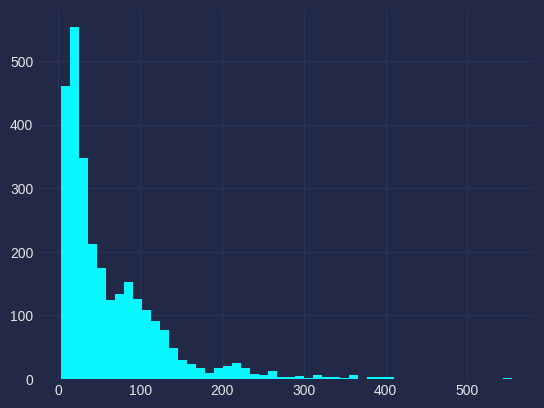

In [416]:
# Считаем длину каждого отзыва (в словах)
lengths = df['cleaned_content_lstm'].apply(lambda x: len(x.split()))

# Смотрим статистику
print(lengths.describe())

# Находим 95-й перцентиль
percentile_95 = lengths.quantile(0.95)
print(f"95% отзывов имеют длину меньше или равную: {percentile_95}")

# Рисуем гистограмму
plt.hist(lengths, bins=50)
plt.show()

In [417]:
def padding(review_int: list, seq_len: int) -> np.array:
    """Make left-sided padding for input list of tokens

    Args:
        review_int (list): input list of tokens
        seq_len (int): max length of sequence, it len(review_int[i]) > seq_len it will be trimmed, else it will be padded by zeros

    Returns:
        np.array: padded sequences
    """    
    features = np.zeros((len(reviews_int), seq_len), dtype = int)
    for i, review in enumerate(review_int):
        if len(review) <= seq_len:
            zeros = list(np.zeros(seq_len - len(review)))
            new = zeros + review
        else:
            new = review[: seq_len] # брали начало
            # new = review[-seq_len:]
        features[i, :] = np.array(new)
            
    return features

In [418]:
SEQ_LEN = 180
features = padding(reviews_int, SEQ_LEN)
print(features[3, :])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0 1743 3295  152
  133  667  938  569 2806  543  213  257  729 3295 1743 3296]


In [419]:
X_train_lstm, X_valid_lstm, y_train_lstm, y_valid_lstm = train_test_split(features, df['label_num'].to_numpy(), test_size=0.25, random_state=42, stratify=df['label_num'])
X_valid_lstm, X_test_lstm, y_valid_lstm, y_test_lstm = train_test_split(X_valid_lstm, y_valid_lstm, test_size=0.2, random_state=42, stratify=y_valid_lstm)
print(f"Обучение (Train): {len(X_train_lstm)} строк")
print(f"Валидация (Val):   {len(X_valid_lstm)} строк")
print(f"Тест (Test):       {len(X_test_lstm)} строк")

Обучение (Train): 2135 строк
Валидация (Val):   569 строк
Тест (Test):       143 строк


In [420]:
train_data = TensorDataset(torch.from_numpy(X_train_lstm), torch.from_numpy(y_train_lstm))
valid_data = TensorDataset(torch.from_numpy(X_valid_lstm), torch.from_numpy(y_valid_lstm))
test_data = TensorDataset(torch.from_numpy(X_test_lstm), torch.from_numpy(y_test_lstm))


BATCH_SIZE = 64

train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=True, batch_size=BATCH_SIZE)

In [421]:
VOCAB_SIZE = len(vocab_to_int)+1 

In [422]:
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

In [423]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [424]:
print(X_train_lstm)
print(y_train_lstm)

[[   0    0    0 ...   28 1713 3177]
 [   0    0    0 ...    1    1  995]
 [   0    0    0 ... 1295  492 2516]
 ...
 [   0    0    0 ...  121 1982  634]
 [   0    0    0 ...  356  237    9]
 [   0    0    0 ...  904 1313  425]]
[1 2 4 ... 4 4 3]


In [425]:
print('Sample input size: BATCH_SIZE x SEQ_LEN', sample_x.size()) # batch_size, seq_length
print('Sample input: \n', sample_x)
print('Sample input: \n', sample_y)

Sample input size: BATCH_SIZE x SEQ_LEN torch.Size([64, 180])
Sample input: 
 tensor([[   0,    0,    0,  ...,  633,  595,   18],
        [   0,    0,    0,  ...,  611, 4004, 2077],
        [   0,    0,    0,  ...,  189,  822,  853],
        ...,
        [   0,    0,    0,  ...,    1,  106,  303],
        [   0,    0,    0,  ..., 4647, 1048, 4659],
        [   0,    0,    0,  ...,    9,  954, 3196]])
Sample input: 
 tensor([4, 4, 1, 2, 0, 1, 2, 4, 2, 0, 0, 3, 1, 1, 3, 0, 1, 1, 0, 1, 2, 3, 3, 1,
        4, 1, 4, 2, 1, 2, 4, 0, 2, 4, 3, 1, 2, 4, 2, 2, 0, 2, 1, 1, 0, 1, 2, 0,
        2, 3, 0, 3, 4, 4, 2, 4, 1, 1, 4, 2, 0, 0, 0, 3])


In [426]:
from dataclasses import dataclass
from typing import Union  # Добавь эту строку
@dataclass
class ConfigRNN:
    vocab_size: int
    device: str
    n_layers: int
    embedding_dim: int
    hidden_size: int
    seq_len: int
    bidirectional: Union[bool, int]
    use_mlflow: bool
    experiment_name: str
    batch_size: int
    epochs: int

In [427]:
hidden_size = 128
embedding_size = 256
n_layers = 2
n_epochs = 10
mlflow_experiment_name = 'NLP-TG-NEWS'

net_config = ConfigRNN(
    vocab_size=len(vocab_to_int) + 1,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    n_layers=n_layers,
    embedding_dim=embedding_size,
    hidden_size=hidden_size,
    seq_len=SEQ_LEN,
    bidirectional=False,
    use_mlflow=True,
    experiment_name=mlflow_experiment_name,
    batch_size=BATCH_SIZE,
    epochs=n_epochs
)
net_config

ConfigRNN(vocab_size=6351, device='cuda', n_layers=2, embedding_dim=256, hidden_size=128, seq_len=180, bidirectional=False, use_mlflow=True, experiment_name='NLP-TG-NEWS', batch_size=64, epochs=10)

In [428]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
import torch.nn as nn

# Создаем метрики
acc_fn = MulticlassAccuracy(num_classes=5, average='micro').to(net_config.device)
f1_fn = MulticlassF1Score(num_classes=5, average='macro').to(net_config.device)

# Объединяем их в словарь для удобства передачи
metrics_dict = {'acc': acc_fn, 'f1': f1_fn}

In [429]:
def train(epochs, model, train_loader, valid_loader, optimizer, criterion, device, metrics, rnn_conf=None):
    result = {
        'train_loss': [], 'valid_loss': [],
        'train_acc': [], 'valid_acc': [],
        'train_f1': [], 'valid_f1': []
    }
    
    # Scheduler оставляем — он полезен для "дожима" точности
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    best_valid_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    time_start = time()
    model.to(device)

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        train_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            metrics['acc'].update(outputs, labels)
            metrics['f1'].update(outputs, labels)
        
        e_train_loss = np.mean(train_losses)
        e_train_acc = metrics['acc'].compute().item()
        e_train_f1 = metrics['f1'].compute().item()
        metrics['acc'].reset(); metrics['f1'].reset()

        # --- VALIDATION ---
        model.eval()
        valid_losses = []
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                valid_losses.append(loss.item())
                metrics['acc'].update(outputs, labels)
                metrics['f1'].update(outputs, labels)

        e_valid_loss = np.mean(valid_losses)
        e_valid_acc = metrics['acc'].compute().item()
        e_valid_f1 = metrics['f1'].compute().item()
        metrics['acc'].reset(); metrics['f1'].reset()

        # --- Scheduler и сохранение лучшего состояния ---
        scheduler.step(e_valid_loss) 

        if e_valid_loss < best_valid_loss:
            best_valid_loss = e_valid_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"  --> Найдена лучшая модель (Loss: {e_valid_loss:.4f})")

        # Сохранение истории
        result['train_loss'].append(e_train_loss)
        result['valid_loss'].append(e_valid_loss)
        result['train_acc'].append(e_train_acc)
        result['valid_acc'].append(e_valid_acc)
        result['train_f1'].append(e_train_f1)
        result['valid_f1'].append(e_valid_f1)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {e_train_loss:.3f}/{e_valid_loss:.3f} | Acc: {e_train_acc:.3f}/{e_valid_acc:.3f} | F1: {e_train_f1:.3f}/{e_valid_f1:.3f}")

    # Загружаем лучшие веса (от самой удачной эпохи) перед выходом
    model.load_state_dict(best_model_wts)
    print(f"\nОбучение завершено. Лучший Valid Loss: {best_valid_loss:.4f}")
    
    return result, time() - time_start

In [430]:
from time import time

def run_train_pipeline(model, optimizer, criterion, train_loader, valid_loader, config, device, metric, run_name="Experiment"):
    """
    Обертка над процессом обучения с поддержкой MLflow
    """
    use_mlflow = config.use_mlflow
    
    if use_mlflow:
        mlflow.set_experiment(config.experiment_name)
        
        with mlflow.start_run(run_name=run_name):
            # 1. Логируем параметры
            mlflow.log_params({
                'batch_size': config.batch_size,
                'hidden_size': config.hidden_size,
                'embedding_dim': config.embedding_dim,                
                'seq_len': config.seq_len,                  
                'epochs': config.epochs,
                'device': str(device),

                # 'encoder': getattr(config, 'encoder', 'unknown') # Вместо .get() используй getattr для объектов
            })


            # 2. Запуск обучения
            start_time = time()
            history, training_time = train(
                epochs=config.epochs, 
                model=model, 
                train_loader=train_loader, 
                valid_loader=valid_loader,
                optimizer=optimizer, 
                criterion=criterion,
                device=device,
                metrics=metric,
                rnn_conf=config
            )
            end_time = time()
            train_time = end_time - start_time
            mlflow.log_metric('work_time_model', train_time)

            # 3. Логируем модель (с учетом ворнинга используем 'name')
            mlflow.pytorch.log_model(model, name='model_rnn')
            
            return history, train_time
    else:
        # Обычный запуск без MLflow
        return train(
                epochs=config.epochs, 
                model=model, 

                train_loader=train_loader, 
                valid_loader=valid_loader,

                optimizer=optimizer, 
                criterion=criterion,
                device=device,
                metrics=metric,
                rnn_conf=config
            )


In [431]:
class LSTMClassifier0(nn.Module):
    def __init__(self, rnn_conf, num_classes=5):
        """
        Классификатор тем на основе LSTM с механизмом внимания через пулинг.
        
        Args:
            rnn_conf: Объект конфигурации (vocab_size, embedding_dim, hidden_size, etc.)
            num_classes: Количество целевых классов (по умолчанию 5)
        """
        super().__init__()
        
        # 1. Инициализация параметров сети
        self.embedding_dim = rnn_conf.embedding_dim
        self.hidden_size = rnn_conf.hidden_size
        self.bidirectional = rnn_conf.bidirectional
        self.n_layers = rnn_conf.n_layers
        self.bidirect_factor = 2 if self.bidirectional else 1
        lstm_out_dim = self.hidden_size * self.bidirect_factor
        
        # 2. Embedding слой
        # padding_idx=0 критичен для игнорирования паддингов при обработке последовательностей разной длины
        self.embedding = nn.Embedding(rnn_conf.vocab_size, self.embedding_dim, padding_idx=0)
        
        # 3. LSTM слой
        # dropout применяется между слоями LSTM (если n_layers > 1) для регуляризации
        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=self.hidden_size,
            num_layers=self.n_layers,
            bidirectional=self.bidirectional,
            batch_first=True,
            dropout=0.7 if self.n_layers > 1 else 0.0
        )
        
        # 4. Классификатор (Fully Connected Head)
        # Входная размерность: lstm_out_dim * 2 (конкатенация Average и Max пулинга)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim * 2, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.62),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x: torch.Tensor):
        """
        Прямой проход через сеть.
        
        Args:
            x: Тензор индексов токенов [batch_size, seq_len]
            
        Returns:
            logits: Логарифмические вероятности классов [batch_size, num_classes]
        """
        # 1. Получение эмбеддингов
        embedded = self.embedding(x)  # [B, L, E]
        
        # 2. Обработка через LSTM
        # lstm_out: [B, L, H * bidirect], скрытые состояния (h_n, c_n) не используются
        lstm_out, _ = self.lstm(embedded)
        
        # 3. Пулинг по временной оси
        # Average Pooling: захватывает общий контекст темы
        avg_pool = torch.mean(lstm_out, dim=1)
        # Max Pooling: захватывает наиболее значимые признаки (ключевые слова)
        max_pool, _ = torch.max(lstm_out, dim=1)
        
        # Конкатенация векторов признаков
        combined = torch.cat((avg_pool, max_pool), dim=1)  # [B, H * 2 * 2]
        
        # 4. Классификация
        logits = self.classifier(combined)
        
        return logits

In [432]:


net_config.hidden_size = 128
net_config.embedding_dim = 256
net_config.seq_len = 200
net_config.epochs = 25

net_config.bidirectional=True
net_config.use_mlflow=False

In [433]:
model_lstm = LSTMClassifier0(net_config)
tu.get_model_summary(model_lstm, sample_x)

Layer                        Kernel          Output        Params              FLOPs
0_embedding                [256, 6351]   [64, 180, 256]   1,625,856           11,520
1_lstm                               -   [64, 180, 256]     790,528   77,160,775,680
2_classifier.Linear_0       [512, 128]        [64, 128]      65,664        8,380,416
3_classifier.LayerNorm_1         [128]        [64, 128]         256                0
4_classifier.ReLU_2                  -        [64, 128]           0                0
5_classifier.Dropout_3               -        [64, 128]           0                0
6_classifier.Linear_4        [128, 64]         [64, 64]       8,256        1,044,480
7_classifier.LayerNorm_5          [64]         [64, 64]         128                0
8_classifier.ReLU_6                  -         [64, 64]           0                0
9_classifier.Dropout_7               -         [64, 64]           0                0
10_classifier.Linear_8         [64, 5]          [64, 5]         3

In [434]:
# net_config.epochs = 30
# net_config.hidden_size = 128 # если было 64
# net_config.embedding_dim = 64 # если было 128
# net_config.bidirectional=True

In [435]:
net_config

ConfigRNN(vocab_size=6351, device='cuda', n_layers=2, embedding_dim=256, hidden_size=128, seq_len=200, bidirectional=True, use_mlflow=False, experiment_name='NLP-TG-NEWS', batch_size=64, epochs=25)

In [436]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
import torch.nn as nn

# Создаем метрики
acc_fn = MulticlassAccuracy(num_classes=5, average='micro').to(net_config.device)
f1_fn = MulticlassF1Score(num_classes=5, average='macro').to(net_config.device)

# Объединяем их в словарь для удобства передачи
metrics_dict = {'acc': acc_fn, 'f1': f1_fn}

In [437]:
# ✅ 1. Оптимизатор — ПРАВИЛЬНАЯ регуляризация
optimizer_lstm = torch.optim.AdamW(
    model_lstm.parameters(), 
    lr=0.0004,        
    weight_decay=0.1  # ❌ БЫЛО 0.00001 → ✅ СТАЛО 0.01
)

# ✅ 2. Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, 
    mode='min', 
    factor=0.5,
    patience=4
)

# ✅ 3. Loss — умеренное сглаживание
weights = torch.tensor([1.4, 1.4, 1.4, 1.6, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(
    weight=weights, 
    label_smoothing=0.2  # ❌ БЫЛО 0.5 → ✅ СТАЛО 0.1
)

In [438]:
# # 1. Оптимизатор — снижаем weight_decay
# optimizer_lstm = torch.optim.AdamW(
#     model_lstm.parameters(), 
#     lr=0.0005,        
#     weight_decay=0.00001 # ↑ в 50 раз
# )

# # 2. Scheduler — более плавное снижение
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer_lstm, 
#     mode='min', 
#     factor=0.5,        # БЫЛО 0.3 → СТАЛО 0.5
#     patience=4
# )

# # 3. Loss — менее агрессивное сглаживание
# weights = torch.tensor([1.6, 1.4, 1.3, 1.5, 1.0]).to(device)
# criterion = nn.CrossEntropyLoss(
#     weight=weights, 
#     label_smoothing=0.5  # ↑ в 2 раза
# )
# Запуск
history, total_time = run_train_pipeline(
    model=model_lstm,
    optimizer=optimizer_lstm,
    criterion=criterion,
    train_loader=train_loader,
    valid_loader=valid_loader,
    config=net_config,
    device=net_config.device,
    metric=metrics_dict, # Передаем словарь метрик
    run_name='LSTM_Final_Run'
)

  --> Найдена лучшая модель (Loss: 1.5629)
Epoch 1/25 | Loss: 1.669/1.563 | Acc: 0.203/0.299 | F1: 0.197/0.200
  --> Найдена лучшая модель (Loss: 1.5362)
Epoch 2/25 | Loss: 1.623/1.536 | Acc: 0.223/0.329 | F1: 0.196/0.216
  --> Найдена лучшая модель (Loss: 1.5111)
Epoch 3/25 | Loss: 1.577/1.511 | Acc: 0.265/0.293 | F1: 0.242/0.163
  --> Найдена лучшая модель (Loss: 1.4807)
Epoch 4/25 | Loss: 1.558/1.481 | Acc: 0.282/0.308 | F1: 0.256/0.180
  --> Найдена лучшая модель (Loss: 1.4109)
Epoch 5/25 | Loss: 1.515/1.411 | Acc: 0.335/0.390 | F1: 0.302/0.273
  --> Найдена лучшая модель (Loss: 1.3094)
Epoch 6/25 | Loss: 1.444/1.309 | Acc: 0.387/0.441 | F1: 0.339/0.310
  --> Найдена лучшая модель (Loss: 1.2602)
Epoch 7/25 | Loss: 1.367/1.260 | Acc: 0.436/0.478 | F1: 0.395/0.389
  --> Найдена лучшая модель (Loss: 1.2011)
Epoch 8/25 | Loss: 1.289/1.201 | Acc: 0.501/0.550 | F1: 0.471/0.483
  --> Найдена лучшая модель (Loss: 1.1662)
Epoch 9/25 | Loss: 1.196/1.166 | Acc: 0.586/0.613 | F1: 0.567/0.565
E

In [439]:
# result_all = {}

In [440]:
result_all['lstm_valid'] = history

Text(0.5, 1.0, 'F1')

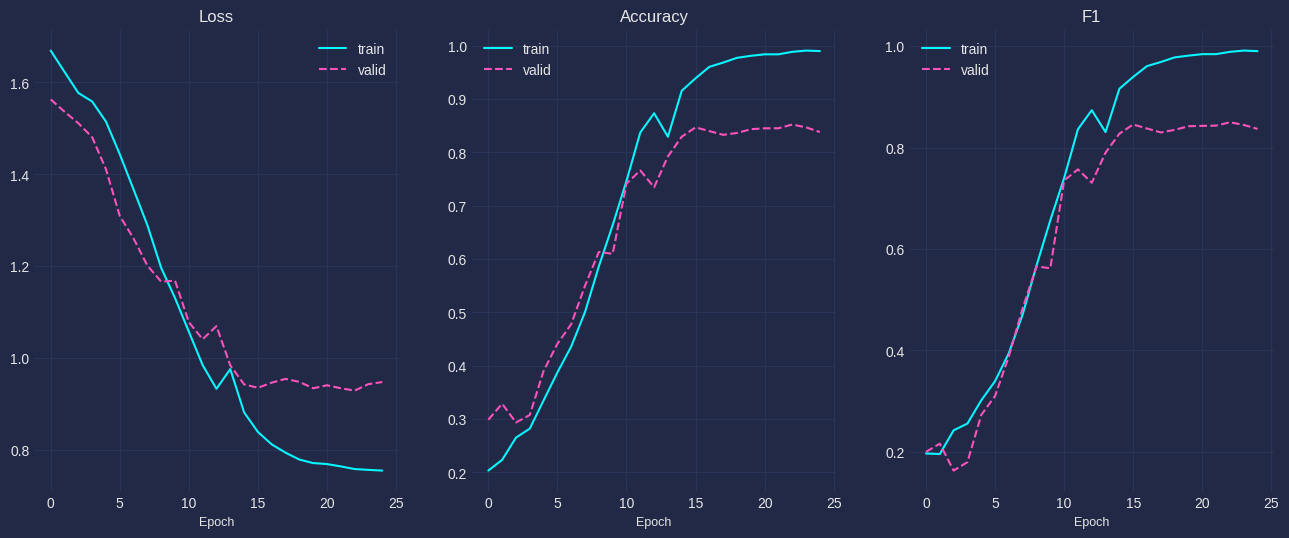

In [441]:
fig = plt.figure(figsize=(16, 6))
ax1 = plt.subplot2grid((1,3), (0,0))
ax1.plot(result_all['lstm_valid']['train_loss'], label='train')
ax1.plot(result_all['lstm_valid']['valid_loss'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Loss')

ax1 = plt.subplot2grid((1,3), (0,1))
ax1.plot(result_all['lstm_valid']['train_acc'], label='train')
ax1.plot(result_all['lstm_valid']['valid_acc'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Accuracy')

ax1 = plt.subplot2grid((1,3), (0,2))
ax1.plot(result_all['lstm_valid']['train_f1'], label='train')
ax1.plot(result_all['lstm_valid']['valid_f1'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'F1')

Accuracy: 0.8524 (85.24%)
F1 Macro: 0.8498

Classification Report:
              precision    recall  f1-score   support

           0     0.8370    0.9496    0.8898       119
           1     0.8173    0.7265    0.7692       117
           2     0.8846    0.7863    0.8326       117
           3     0.9091    0.9483    0.9283       116
           4     0.8095    0.8500    0.8293       100

    accuracy                         0.8524       569
   macro avg     0.8515    0.8521    0.8498       569
weighted avg     0.8526    0.8524    0.8504       569


Confusion Matrix:
[[113   3   0   0   3]
 [ 15  85   5   2  10]
 [  1  10  92   8   6]
 [  0   2   3 110   1]
 [  6   4   4   1  85]]


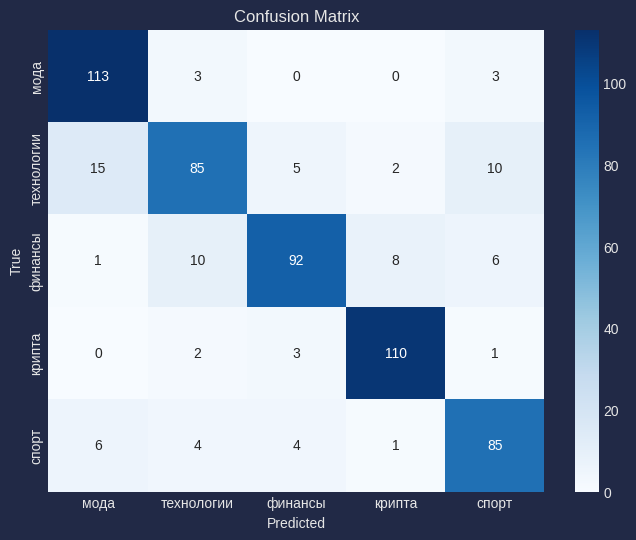

In [442]:
model_lstm.eval()
all_preds = []
all_labels = []
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 


with torch.no_grad():
    for batch in valid_loader:
        x, y = batch[0].to(net_config.device), batch[1].to(net_config.device)
        outputs = model_lstm(x)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# ==================== МЕТРИКИ ====================

accuracy = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Macro: {f1_macro:.4f}")

# ==================== CLASSIFICATION REPORT ====================

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# ==================== CONFUSION MATRIX ====================

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# ==================== ВИЗУАЛИЗАЦИЯ (опционально) ====================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

сохраним модель и веса LSTM

In [443]:
save_path = 'models/lstm_tg'
os.makedirs(save_path, exist_ok=True)

# 1. Сохраняем только веса (state_dict) - это Best Practice
torch.save(model_lstm.state_dict(), os.path.join(save_path, 'model_lstm_weights.pt'))

# 2. Сохраняем конфигурацию архитектуры (чтобы воссоздать модель)
net_config_dict = {
    'vocab_size': net_config.vocab_size,
    'embedding_dim': net_config.embedding_dim,
    'hidden_size': net_config.hidden_size,
    'bidirectional': net_config.bidirectional,
    'n_layers': net_config.n_layers
}
with open(os.path.join(save_path, 'rnn_config.json'), 'w', encoding='utf-8') as f:
    json.dump(net_config_dict, f, ensure_ascii=False, indent=2)

# 3. Сохраняем словарь токенов
with open(os.path.join(save_path, 'vocab_to_int.pkl'), 'wb') as f:
    pickle.dump(vocab_to_int, f)

# 4. Сохраняем параметры предобработки (КРИТИЧНО!)
preprocessing_config = {
    'max_len': net_config.seq_len,          # Укажите вашу реальную длину
    'padding_value': 0,      # Укажите ваше значение
    'tokenizer': 'simple'    # Или название вашего токенизатора
}
with open(os.path.join(save_path, 'preprocessing_config.json'), 'w', encoding='utf-8') as f:
    json.dump(preprocessing_config, f, ensure_ascii=False, indent=2)

# 5. Сохраняем маппинг классов
class_mapping = {0: 'мода', 1: 'технологии', 2: 'финансы', 3: 'крипта', 4: 'спорт'}
with open(os.path.join(save_path, 'class_mapping.json'), 'w', encoding='utf-8') as f:
    json.dump(class_mapping, f, ensure_ascii=False, indent=2)

print("✅ Все артефакты для деплоя сохранены!")

✅ Все артефакты для деплоя сохранены!


In [444]:
# save_path = 'models/lstm_tg'
# os.makedirs(save_path, exist_ok=True)

# # 1. Сохраняем веса (самый надежный способ)
# torch.save(model_lstm.state_dict(), os.path.join(save_path, 'model_lstm_weights.pt'))

# # 2. Сохраняем всю модель (может потребовать импорт класса при загрузке)
# torch.save(model_lstm, os.path.join(save_path, 'model_lstm_full.pt'))

# # 3. ИСПРАВЛЕНО: Сохраняем словарь (vocab_to_int)
# # Ошибка была здесь: закрывающая скобка стояла не там
# with open(os.path.join(save_path, 'vocab_to_int_lstm.pkl'), 'wb') as f:
#     pickle.dump(vocab_to_int, f)

# print("Модель LSTM и словарь успешно сохранены!")


In [445]:
# def predict(text, model, vocab_to_int, max_len):
#     # 1. Предобработка (используй ту же функцию clean_lstm, что и при обучении)
#     cleaned_text = clean_lstm(text)
    
#     # 2. Токенизация через твой словарь vocab_to_int
#     # (как в твоей ячейке [4] на скриншоте)
#     sequence = [vocab_to_int[word] for word in cleaned_text.split() if word in vocab_to_int]
    
#     # 3. Padding (дополнение нулями или обрезка)
#     if len(sequence) < max_len:
#         # Добавляем нули слева (как обычно в LSTM)
#         padded_sequence = [0] * (max_len - len(sequence)) + sequence
#     else:
#         # Обрезаем до нужной длины
#         padded_sequence = sequence[:max_len]
    
#     # 4. Перевод в тензор и инференс
#     model.eval()
#     with torch.no_grad():
#         # Создаем тензор и сразу отправляем его на GPU (или CPU, если модель там)
#         inputs = torch.LongTensor([padded_sequence]).to(device) 
        
#         output = model(inputs)
        
#         # Получаем вероятности (если на выходе логиты)
#         probs = torch.softmax(output, dim=1)
#         # Получаем индекс самого вероятного класса
#         prediction = torch.argmax(probs, dim=1).item()
        
#     return prediction, probs

# max_len = int(percentile_95) 
# text_to_check = "Долар снова растет"

# # Получаем индекс и все вероятности
# pred_idx, probs = predict(text_to_check, model_lstm, vocab_to_int, max_len)

# # Создаем обратный маппинг, чтобы по индексу получить название
# inv_mapping = {v: k for k, v in mapping.items()}

# category = inv_mapping[pred_idx]
# confidence = probs[0][pred_idx].item() # Берем вероятность предсказанного класса

# print(f"Текст: {text_to_check}")
# print(f"Результат классификации: {category.upper()}")
# print(f"Уверенность: {confidence:.2%}")

In [446]:
# def check_problem(text, model, vocab_to_int, max_len):
#     cleaned = clean_lstm(text)
#     # 1. Проверяем, находит ли модель слова в словаре
#     sequence = [vocab_to_int[word] for word in cleaned.split() if word in vocab_to_int]
    
#     print(f"--- Текст: {text} ---")
#     print(f"Очищенный: {cleaned}")
#     print(f"Индексы слов (должны быть > 0): {sequence}")
    
#     if not sequence:
#         print("ВНИМАНИЕ: Модель не узнала ни одного слова! Проверь лемматизацию или опечатки.")
#         return
        
#     # 2. Проверяем размерность тензора перед моделью
#     # Паддинг должен быть нулями
#     padded = [0] * (max_len - len(sequence)) + sequence if len(sequence) < max_len else sequence[:max_len]
#     inputs = torch.LongTensor([padded]).to(device)
    
#     print(f"Форма тензора (должна быть [1, {max_len}]): {inputs.shape}")
    
#     model.eval()
#     with torch.no_grad():
#         output = model(inputs)
#         probs = torch.softmax(output, dim=1)
#         print(f"Сырые вероятности всех классов: {probs.cpu().numpy()}")
        
# check_problem("Доллар курс акции", model_lstm, vocab_to_int, max_len)

### BERT

In [447]:
def data_preprocessing(text: str) -> str:
    if not isinstance(text, str):
        return ""
    
    # 1. HTML-теги — удалить (шум)
    text = re.sub('<.*?>', '', text)
    
    # 2. Ссылки — удалить (не было в предобучении)
    text = re.sub(r'https?://\S+', ' ', text)
    
    # 3. @упоминания — удалить
    text = re.sub(r'@\w+', ' ', text)
    
    # 4. Регистр — ТОЛЬКО если используешь uncased модель
    # Для rubert-base-cased — НЕ lower()!
    # text = text.lower()
    
    # 5. ВСЁ остальное оставить (пунктуация, цифры, эмодзи, стоп-слова)

    text = re.sub(r'([.,!?/])', r' \1 ', text) # Добавляет пробелы вокруг знаков
    text = re.sub(r'\s+', ' ', text)            # Убирает лишние пробелы
    
    return text.strip()



In [448]:
def data_preprocessing(text: str) -> str:
    if not isinstance(text, str): return ""
    
    text = text.lower()
    # Список слов, которые модель "переучила" во вред
    confusing_words = ['доллар', 'доллары', 'доллара', 'долларов', 'usd']
    
    for word in confusing_words:
        text = re.sub(rf'\b{word}\b', '', text)
        
    # Ваш старый код (ссылки, теги и т.д.)
    text = re.sub('<.*?>', '', text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [449]:
# Загрузка данных
df = pd.read_feather('data/tg_channels.feather')

print(df.head())

df = df.dropna(subset=['content'])
df['label_num'] = df['label'].map(mapping)

                               url                      date  \
0  https://t.me/s/russianmoda/5961 2023-09-17 17:09:06+00:00   
1  https://t.me/s/russianmoda/5957 2023-09-17 12:09:06+00:00   
2  https://t.me/s/russianmoda/5951 2023-09-17 06:09:06+00:00   
3  https://t.me/s/russianmoda/5939 2023-09-16 17:09:06+00:00   
4  https://t.me/s/russianmoda/5935 2023-09-16 12:09:06+00:00   

                                             content label  
0  Широкие бедра всегда считались роскошью и прид...  мода  
1  Не знаю как у вас, но у меня ни одна осень не ...  мода  
2  Осенью настроение немножко ухудшается. Этому с...  мода  
3  Кардиган очень коварен в стилизации, поэтому е...  мода  
4  Трикотажные костюмы часто ассоциируются с брюк...  мода  


In [450]:
df.isna().mean()

url          0.0
date         0.0
content      0.0
label        0.0
label_num    0.0
dtype: float64

In [451]:
df['cleaned_content_bert'] = df['content'].apply(data_preprocessing)

In [452]:
corpus = [word for text in df['cleaned_content_bert'] for word in text.split()]
count_words = Counter(corpus)

sorted_words = count_words.most_common()

In [453]:
def get_words_by_freq(sorted_words: list, n: int = 10) -> list:
    return list(filter(lambda x: x[1] > n, sorted_words))

In [454]:
print(len(sorted_words))


66163


In [455]:
sorted_words = get_words_by_freq(sorted_words, 1)
print(len(sorted_words))

21636


In [456]:
vocab_to_int = {w:i+1 for i, (w,c) in enumerate(sorted_words)}

In [457]:
reviews_int = []
for text in df['cleaned_content_bert']:

    r = [vocab_to_int[word] for word in text.split() if vocab_to_int.get(word)]
    reviews_int.append(r)

In [458]:
print([i for i in reviews_int[99]])

[107, 15, 351, 3085, 1168, 4, 12978, 27, 12979, 36, 4, 12980, 9086, 9110, 4687, 5555, 2, 773, 73, 1241, 4669, 181, 2, 4, 9113, 26]


In [459]:
review_len = [len(x) for x in reviews_int]
df['Review_len_bert'] = review_len
df.head()

,url,date,content,label,label_num,cleaned_content_bert,Review_len_bert
0,https://t.me/s/russianmoda/5961,2023-09-17 17:09:06+00:00,Широкие бедра всегда считались роскошью и прид...,мода,0,широкие бедра всегда считались роскошью и прид...,39
1,https://t.me/s/russianmoda/5957,2023-09-17 12:09:06+00:00,"Не знаю как у вас, но у меня ни одна осень не ...",мода,0,"не знаю как у вас, но у меня ни одна осень не ...",30
2,https://t.me/s/russianmoda/5951,2023-09-17 06:09:06+00:00,Осенью настроение немножко ухудшается. Этому с...,мода,0,осенью настроение немножко ухудшается. этому с...,55
3,https://t.me/s/russianmoda/5939,2023-09-16 17:09:06+00:00,"Кардиган очень коварен в стилизации, поэтому е...",мода,0,"кардиган очень коварен в стилизации, поэтому е...",19
4,https://t.me/s/russianmoda/5935,2023-09-16 12:09:06+00:00,Трикотажные костюмы часто ассоциируются с брюк...,мода,0,трикотажные костюмы часто ассоциируются с брюк...,37


In [460]:
df = df[df['Review_len_bert'] >= 2].copy()

In [461]:
print(df['Review_len_bert'].describe())

count    2847.000000
mean       73.807517
std        77.052411
min         2.000000
25%        21.500000
50%        46.000000
75%       103.000000
max       568.000000
Name: Review_len_bert, dtype: float64


In [462]:
print(f"95% отзывов имеют длину меньше или равную: {df['Review_len_bert'].quantile(0.95)}")

95% отзывов имеют длину меньше или равную: 236.39999999999964


count    2847.000000
mean       89.442922
std        90.238807
min         3.000000
25%        27.000000
50%        57.000000
75%       127.000000
max       643.000000
Name: cleaned_content_bert, dtype: float64
95% отзывов имеют длину меньше или равную: 277.0


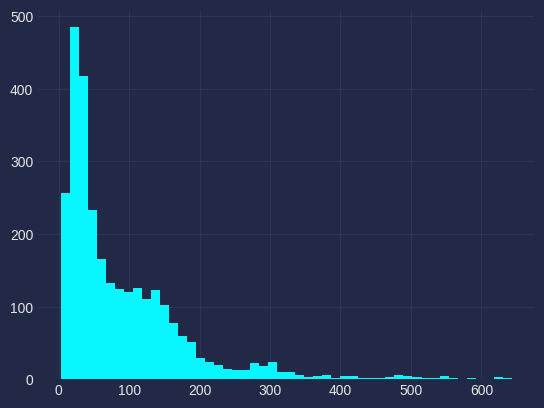

In [463]:
# Считаем длину каждого отзыва (в словах)
lengths = df['cleaned_content_bert'].apply(lambda x: len(x.split()))

# Смотрим статистику
print(lengths.describe())

# Находим 95-й перцентиль
percentile_95 = lengths.quantile(0.95)
print(f"95% отзывов имеют длину меньше или равную: {percentile_95}")

# Рисуем гистограмму
plt.hist(lengths, bins=50)
plt.show()

In [464]:
SEQ_LEN = 277

In [465]:
net_config.seq_len = SEQ_LEN

In [466]:
net_config

ConfigRNN(vocab_size=6351, device='cuda', n_layers=2, embedding_dim=256, hidden_size=128, seq_len=277, bidirectional=True, use_mlflow=False, experiment_name='NLP-TG-NEWS', batch_size=64, epochs=25)

In [467]:
import torch
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
model_rubert = AutoModel.from_pretrained("cointegrated/rubert-tiny2")

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 2368.74it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [468]:
encoded_input = tokenizer(df['cleaned_content_bert'][0], return_tensors='pt')
print(encoded_input)

{'input_ids': tensor([[    2, 41810, 51914, 13157, 48138, 58696,   920,   320, 67766,  3782,
         21912,  1550, 76387, 32397,    16,   312, 18754, 31369, 41104, 31972,
          4884,  3203, 10587,   320, 30733, 71770, 22234,    18, 19389, 32608,
           320, 59194, 10662, 29590,  1129, 56499, 55705, 59053,   870,     1,
          2389, 42180, 39494, 30540,  1160, 42859,  9097,   320, 49100, 48423,
          3414,   314, 35940, 14066, 31892,  1305,    16,  1046, 50311, 70991,
          3825, 34043, 33825,    18, 62228, 18646,  3658,  5073, 83747, 11079,
         75051,   870, 74905,     3]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 

In [469]:
encoded_tgnews = df['cleaned_content_bert'].progress_apply(
    lambda x: tokenizer(x, max_length=net_config.seq_len, truncation=True, padding='max_length')
).values

100%|██████████| 2847/2847 [00:00<00:00, 2993.58it/s]


In [470]:
tokenizer.decode(222)

'ź'

In [471]:
len(encoded_tgnews)

2847

In [472]:
encoded_tgnews

array([{'input_ids': [2, 41810, 51914, 13157, 48138, 58696, 920, 320, 67766, 3782, 21912, 1550, 76387, 32397, 16, 312, 18754, 31369, 41104, 31972, 4884, 3203, 10587, 320, 30733, 71770, 22234, 18, 19389, 32608, 320, 59194, 10662, 29590, 1129, 56499, 55705, 59053, 870, 1, 2389, 42180, 39494, 30540, 1160, 42859, 9097, 320, 49100, 48423, 3414, 314, 35940, 14066, 31892, 1305, 16, 1046, 50311, 70991, 3825, 34043, 33825, 18, 62228, 18646, 3658, 5073, 83747, 11079, 75051, 870, 74905, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [473]:
class BertInputs(torch.utils.data.Dataset):
    def __init__(self, encoded_tgnews):
        self.inputs = encoded_tgnews

    def __len__(self):
        return self.inputs.shape[0]
    
    def __getitem__(self, idx):
        return (
            torch.Tensor(self.inputs[idx]['input_ids']).cuda().long(),
            torch.Tensor(self.inputs[idx]['attention_mask']).cuda().long()
        )
    
dataset = BertInputs(encoded_tgnews)

In [474]:
loader = torch.utils.data.DataLoader(dataset, batch_size=net_config.batch_size, shuffle=False)

In [475]:
batch = next(iter(loader))
batch

[tensor([[    2, 41810, 51914,  ...,     0,     0,     0],
         [    2,   769, 30310,  ...,     0,     0,     0],
         [    2, 32886, 34926,  ...,     0,     0,     0],
         ...,
         [    2, 19389, 32608,  ...,     0,     0,     0],
         [    2,   548, 31761,  ...,     0,     0,     0],
         [    2, 62228, 17325,  ...,     0,     0,     0]], device='cuda:0'),
 tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]], device='cuda:0')]

In [476]:
train_data, valid_data, y_train, y_valid = train_test_split(
    encoded_tgnews, df['label_num'].to_numpy(), test_size=0.25, random_state=42, stratify=df['label_num']
)

valid_data, test_data, y_valid, y_test = train_test_split(valid_data, y_valid, test_size=0.2, random_state=42, stratify=y_valid)

In [477]:
# 3. Создаем лоадеры, которые выдают словари
class BertFinalDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels):
        self.data, self.labels = data, labels
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            'input_ids': torch.tensor(item['input_ids']).long(),
            'attention_mask': torch.tensor(item['attention_mask']).long()
        }, torch.tensor(self.labels[idx]).float()

In [478]:
train_loader = DataLoader(BertFinalDataset(train_data, y_train), batch_size=net_config.batch_size, shuffle=True)
valid_loader = DataLoader(BertFinalDataset(valid_data, y_valid), batch_size=net_config.batch_size)
test_loader = DataLoader(BertFinalDataset(test_data, y_test), batch_size=net_config.batch_size)

In [479]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
model = AutoModelForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny2",
    num_labels=5  # Твои 5 классов
)

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 2178.08it/s, Materializing param=bert.pooler.dense.weight]                              
BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/archi

In [480]:
class MyBERTFreeze(nn.Module):
    def __init__(self, num_labels=5):
        super().__init__()
        self.bert = transformers.BertModel.from_pretrained("cointegrated/rubert-tiny2")
        
        # Заморозка BERT
        for param in self.bert.parameters():
            param.requires_grad = False
        
        hidden_size = self.bert.config.hidden_size  # 312 для rubert-tiny2
        
        self.linear = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    # def forward(self, x):
    #     device = next(self.parameters()).device
    #     inputs = {k: v.to(device) for k, v in x.items()}
    #     bert_out = self.bert(**inputs)
    #     cls_token = bert_out.last_hidden_state[:, 0, :]
    #     return self.linear(cls_token)
    
    def forward(self, input_ids, attention_mask, **kwargs):
        # Прогоняем через BERT
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Берём [CLS] токен (первый токен в последовательности)
        # last_hidden_state имеет размер [batch_size, seq_len, hidden_size]
        cls_token = bert_out.last_hidden_state[:, 0, :]
        
        # Прогоняем через классификатор
        logits = self.linear(cls_token)
        return logits

In [481]:
batch = next(iter(train_loader))

In [482]:
mybert_freeze = MyBERTFreeze(num_labels=5).to(device)


Loading weights: 100%|██████████| 55/55 [00:00<00:00, 2532.74it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [483]:
optimizer_bert_f = torch.optim.AdamW(mybert_freeze.parameters(), weight_decay=0.2, lr=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_bert_f, 
    mode='min',    # будем следить за уменьшением val_loss
    patience=2,    # если 1 эпоху лосс не падает — снижаем LR
    factor=0.5,    # снижаем в 2 раза
    # verbose=True   # чтобы видеть в консоли, когда LR упал
)

criterion = nn.CrossEntropyLoss()

In [484]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

acc_metric = MulticlassAccuracy(num_classes=5, average='micro').to(device)
f1_metric = MulticlassF1Score(num_classes=5, average='macro').to(device)

In [485]:
import mlflow
import mlflow.pytorch
import torch
import numpy as np
from tqdm import tqdm

def train_bert_model(model, train_loader, valid_loader, optimizer, criterion, 
                     epochs, device, config, run_name, scheduler=None):
    
    # --- MLFLOW ---
    mlflow.set_experiment(config.experiment_name)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            "epochs": epochs,
            "learning_rate": optimizer.param_groups[0]['lr'],
            "batch_size": config.batch_size,
            "model": "rubert-tiny2"
        })

        for epoch in range(epochs):
            # --- TRAIN ---
            model.train()
            train_losses, tr_accs, tr_f1s = [], [], []
            
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
                optimizer.zero_grad()
                
                # ✅ Обработка batch (dict или list)
                if isinstance(batch, dict):
                    labels = batch['labels'].to(device).long()
                    inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
                
                elif isinstance(batch, (list, tuple)) and len(batch) == 3:
                    inputs = {'input_ids': batch[0].to(device), 'attention_mask': batch[1].to(device)}
                    labels = batch[2].to(device).long()
                
                elif isinstance(batch, (list, tuple)) and len(batch) == 2:
                    if isinstance(batch[0], dict):
                        inputs = {k: v.to(device) for k, v in batch[0].items()}
                    elif isinstance(batch[0], (tuple, list)):
                        inputs = {'input_ids': batch[0][0].to(device), 'attention_mask': batch[0][1].to(device)}
                    else:
                        inputs = {'input_ids': batch[0].to(device)}
                    labels = batch[1].to(device).long()
                
                else:
                    raise ValueError(f"Unknown batch format: {type(batch)}")
                
                logits = model(**inputs)
                loss = criterion(logits, labels)
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_losses.append(loss.item())
                tr_accs.append(acc_metric(logits, labels).item())
                tr_f1s.append(f1_metric(logits, labels).item())

            # --- VALIDATION ---
            model.eval()
            val_losses, val_accs, val_f1s = [], [], []
            
            with torch.no_grad():
                for batch in tqdm(valid_loader, desc=f"[Valid]"):
                    # ✅ ИСПРАВЛЕНО: та же логика что в TRAIN
                    if isinstance(batch, dict):
                        labels = batch['labels'].to(device).long()
                        inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
                    
                    elif isinstance(batch, (list, tuple)) and len(batch) == 3:
                        inputs = {'input_ids': batch[0].to(device), 'attention_mask': batch[1].to(device)}
                        labels = batch[2].to(device).long()
                    
                    elif isinstance(batch, (list, tuple)) and len(batch) == 2:
                        if isinstance(batch[0], dict):
                            # ✅ Исправлено: dict не имеет .to(), перебираем элементы
                            inputs = {k: v.to(device) for k, v in batch[0].items()}
                        elif isinstance(batch[0], (tuple, list)):
                            inputs = {'input_ids': batch[0][0].to(device), 'attention_mask': batch[0][1].to(device)}
                        else:
                            inputs = {'input_ids': batch[0].to(device)}
                        labels = batch[1].to(device).long()
                    
                    logits = model(**inputs)
                    loss = criterion(logits, labels)
                    
                    val_losses.append(loss.item())
                    val_accs.append(acc_metric(logits, labels).item())
                    val_f1s.append(f1_metric(logits, labels).item())

            # --- METRICS ---
            e_train_loss = np.mean(train_losses)
            e_val_loss = np.mean(val_losses)
            e_val_acc = np.mean(val_accs)
            e_val_f1 = np.mean(val_f1s)

            # --- MLFLOW LOGGING ---
            mlflow.log_metrics({
                'train_loss': e_train_loss,
                'val_loss': e_val_loss,
                'val_accuracy': e_val_acc,
                'val_f1': e_val_f1,
            }, step=epoch)

            history['train_loss'].append(e_train_loss)
            history['val_loss'].append(e_val_loss)
            history['train_acc'].append(np.mean(tr_accs))
            history['val_acc'].append(e_val_acc)
            history['train_f1'].append(np.mean(tr_f1s))
            history['val_f1'].append(e_val_f1)

            # Scheduler
            if scheduler is not None:
                scheduler.step(e_val_loss)
                mlflow.log_metric("learning_rate", optimizer.param_groups[0]['lr'], step=epoch)

            # --- PRINT ---
            print(f"\nEpoch {epoch+1}:")
            print(f"Loss: Train {e_train_loss:.4f} | Val {e_val_loss:.4f}")
            print(f"Acc:  Train {history['train_acc'][-1]:.4f} | Val {e_val_acc:.4f}")
            print(f"F1:   Train {history['train_f1'][-1]:.4f} | Val {e_val_f1:.4f}")
            print("-" * 30)

        # Save model
        mlflow.pytorch.log_model(model, "model_bert_final")

    return history

In [486]:
net_config.experiment_name = "BERT_Sentiment_Project"

results = train_bert_model(
    model=mybert_freeze,
    train_loader=train_loader,
    valid_loader=valid_loader,
    optimizer=optimizer_bert_f,
    criterion=criterion,
    epochs=10,
    device=net_config.device,
    config=net_config,
    run_name="BERT_Unfreeze_Layer11_Run1" # Название этапа
)

[Valid]: 100%|██████████| 9/9 [00:01<00:00,  7.12it/s]



Epoch 1:
Loss: Train 1.1958 | Val 0.7552
Acc:  Train 0.6602 | Val 0.8468
F1:   Train 0.6419 | Val 0.8401
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.91it/s]



Epoch 2:
Loss: Train 0.6042 | Val 0.4544
Acc:  Train 0.8382 | Val 0.8666
F1:   Train 0.8348 | Val 0.8635
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.86it/s]


...


Epoch 8:
Loss: Train 0.2676 | Val 0.2958
Acc:  Train 0.9154 | Val 0.8930
F1:   Train 0.9135 | Val 0.8916
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.71it/s]



Epoch 9:
Loss: Train 0.2571 | Val 0.2801
Acc:  Train 0.9101 | Val 0.9002
F1:   Train 0.9093 | Val 0.8994
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.76it/s]
2026/03/01 19:01:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 19:01:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.



Epoch 10:
Loss: Train 0.2430 | Val 0.2764
Acc:  Train 0.9169 | Val 0.9052
F1:   Train 0.9134 | Val 0.9042
------------------------------


Accuracy: 0.9051 (90.51%)
F1 Macro: 0.9060

Classification Report:
              precision    recall  f1-score   support

         0.0     0.8898    0.9496    0.9187       119
         1.0     0.8870    0.8718    0.8793       117
         2.0     0.8938    0.8632    0.8783       117
         3.0     0.9204    0.8966    0.9083       116
         4.0     0.9406    0.9500    0.9453       100

    accuracy                         0.9051       569
   macro avg     0.9063    0.9062    0.9060       569
weighted avg     0.9052    0.9051    0.9048       569


Confusion Matrix:
[[113   2   1   0   3]
 [ 10 102   3   0   2]
 [  0   7 101   9   0]
 [  0   3   8 104   1]
 [  4   1   0   0  95]]


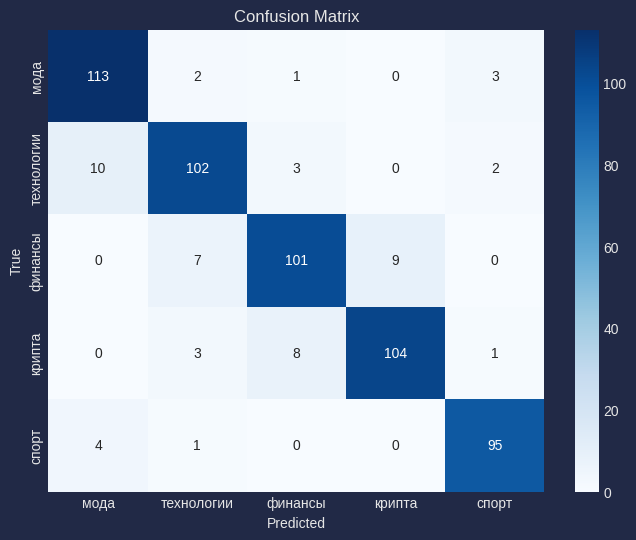

In [487]:
mybert_freeze.eval()
all_preds = []
all_labels = []
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

with torch.no_grad():
    for batch in valid_loader:
        # ✅ Простая проверка
        if isinstance(batch, dict):
            # batch = {'input_ids': ..., 'attention_mask': ..., 'labels': ...}
            inputs = {k: v.to(net_config.device) for k, v in batch.items() if k != 'labels'}
            y = batch['labels'].to(net_config.device)
        else:
            # batch = [inputs_dict, labels]
            inputs = batch[0]
            if isinstance(inputs, dict):
                inputs = {k: v.to(net_config.device) for k, v in inputs.items()}
            else:
                inputs = inputs.to(net_config.device)
            y = batch[1].to(net_config.device)
        
        outputs = mybert_freeze(**inputs) 
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# МЕТРИКИ
accuracy = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Macro: {f1_macro:.4f}")

# CLASSIFICATION REPORT
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# CONFUSION MATRIX
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [488]:
result_all['bert_freeze_valid'] = results

In [489]:
results.keys()

dict_keys(['train_loss', 'val_loss', 'train_acc', 'val_acc', 'train_f1', 'val_f1'])

In [490]:
result_all['bert_freeze_valid'] = results

Text(0.5, 1.0, 'F1')

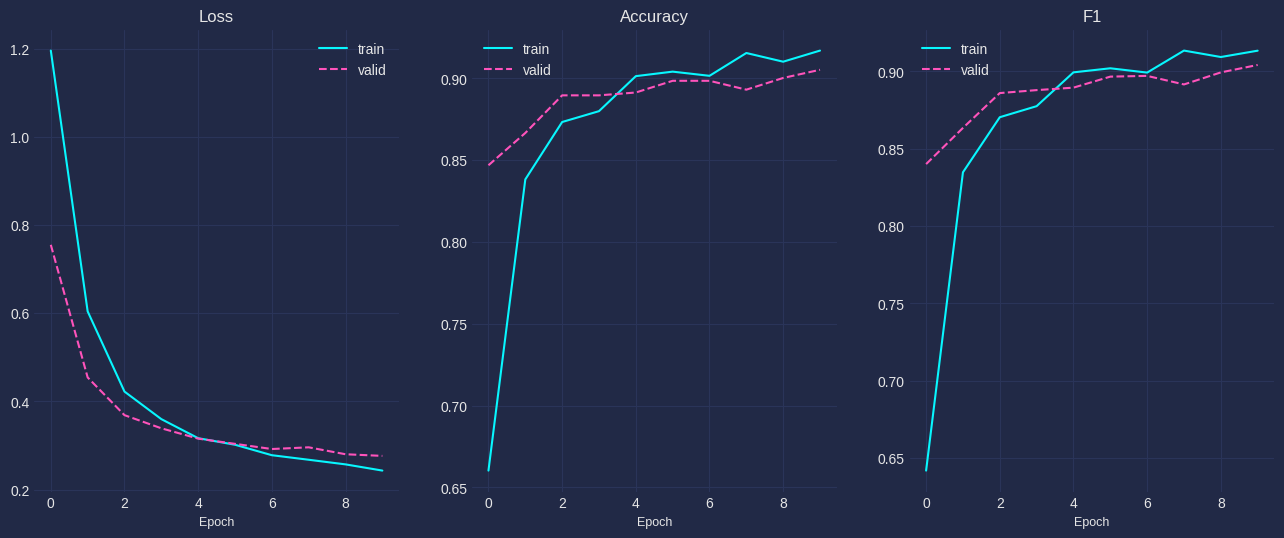

In [491]:
result_all['bert_freeze_valid'] = results
fig = plt.figure(figsize=(16, 6))
ax1 = plt.subplot2grid((1,3), (0,0))
ax1.plot(result_all['bert_freeze_valid']['train_loss'], label='train')
ax1.plot(result_all['bert_freeze_valid']['val_loss'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Loss')

ax1 = plt.subplot2grid((1,3), (0,1))
ax1.plot(result_all['bert_freeze_valid']['train_acc'], label='train')
ax1.plot(result_all['bert_freeze_valid']['val_acc'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Accuracy')

ax1 = plt.subplot2grid((1,3), (0,2))
ax1.plot(result_all['bert_freeze_valid']['train_f1'], label='train')
ax1.plot(result_all['bert_freeze_valid']['val_f1'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'F1')

In [492]:
# Сохраняем только веса (state_dict) — это самый надежный способ
torch.save(mybert_freeze.state_dict(), 'models/model_lstm_weights.pt')
print("Веса замороженной модели сохранены!")

Веса замороженной модели сохранены!


### Размораживаем слои BERT

In [493]:
class MyBERTUnFreeze(nn.Module):
    def __init__(self, num_labels=5):
        super().__init__()
        self.bert = transformers.BertModel.from_pretrained("cointegrated/rubert-tiny2")
        hidden_size = self.bert.config.hidden_size 
        num_layers = self.bert.config.num_hidden_layers 
        
        # 1. Замораживаем всё
        for param in self.bert.parameters():
            param.requires_grad = False
            
        # 2. Размораживаем последний слой и пулер
        for param in self.bert.encoder.layer[num_layers - 1].parameters():
            param.requires_grad = True
        for param in self.bert.pooler.parameters():
            param.requires_grad = True

        # 3. Классификатор
        self.linear = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_labels)
        )


    def forward(self, input_ids, attention_mask, **kwargs):
        # Прогоняем через BERT
        # Тензоры уже должны быть на нужном устройстве (cpu или cuda)
        device = next(self.parameters()).device
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Берем pooler_output (вектор [CLS] токена)
        pooled_output = bert_out.pooler_output
        
        # Финальный классификатор
        logits = self.linear(pooled_output)
        
        return logits
    


In [494]:
mybert_unfreeze = MyBERTUnFreeze(num_labels=5).to(device)

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 2680.32it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [495]:
# mybert_unfreeze.load_state_dict(torch.load('models/bert_frozen_model.pth'), strict=False)
# print("Веса успешно загружены в размороженную модель!")

In [496]:
net_config.batch_size = 128
net_config

ConfigRNN(vocab_size=6351, device='cuda', n_layers=2, embedding_dim=256, hidden_size=128, seq_len=277, bidirectional=True, use_mlflow=False, experiment_name='BERT_Sentiment_Project', batch_size=128, epochs=25)

In [497]:
# bert_params = (
#     list(mybert_unfreeze.bert.encoder.layer[-2].parameters()) + # Предпоследний (1-й) слой
#     list(mybert_unfreeze.bert.encoder.layer[-1].parameters()) + # Последний (2-й) слой
#     list(mybert_unfreeze.bert.pooler.parameters())              # Пулер
# )

# # 2. Параметры твоего кастомного классификатора (nn.Sequential)
# classifier_params = list(mybert_unfreeze.linear.parameters())

# # 3. Оптимизатор с дифференциальным обучением (Discriminative Learning Rates)
# optimizer_unfreeze = torch.optim.AdamW([
#     # Для BERT ставим очень маленький LR, чтобы не «сломать» предобученные веса
#     {'params': bert_params, 'lr': 3e-5},      
#     # Для классификатора (он новый) ставим LR побольше
#     {'params': classifier_params, 'lr': 3e-4} 
# ], weight_decay=0.08) # Умеренный weight_decay для регуляризации

# # 4. Функция потерь
# # ВАЖНО: Если у тебя задача классификации на 5 взаимоисключающих классов, 
# # лучше использовать CrossEntropyLoss(). 
# # BCEWithLogitsLoss обычно используется для Multi-label (когда у текста может быть несколько тегов).
# criterion = nn.CrossEntropyLoss()

In [498]:
optimizer_unfreeze = torch.optim.AdamW(mybert_unfreeze.parameters(), weight_decay=0.8, lr=0.00005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_unfreeze, 
    mode='min',    # будем следить за уменьшением val_loss
    patience=2,    # если 1 эпоху лосс не падает — снижаем LR
    factor=0.5,    # снижаем в 2 раза
    # verbose=True   # чтобы видеть в консоли, когда LR упал
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [499]:
results_unfreeze = train_bert_model(
    model=mybert_unfreeze,
    train_loader=train_loader,
    valid_loader=valid_loader,
    optimizer=optimizer_unfreeze,
    criterion=criterion,
    epochs=20, 
    device=net_config.device,
    config=net_config,
    run_name="BERT_Unfreeze_Fine_tun_1"
)

[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.99it/s]



Epoch 1:
Loss: Train 1.5556 | Val 1.4682
Acc:  Train 0.4663 | Val 0.7856
F1:   Train 0.4407 | Val 0.7785
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.79it/s]



Epoch 2:
Loss: Train 1.3208 | Val 1.1063
Acc:  Train 0.7264 | Val 0.7770
F1:   Train 0.7173 | Val 0.7690
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.74it/s]


...


Epoch 18:
Loss: Train 0.4762 | Val 0.5074
Acc:  Train 0.9785 | Val 0.9527
F1:   Train 0.9777 | Val 0.9523
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.67it/s]



Epoch 19:
Loss: Train 0.4714 | Val 0.5100
Acc:  Train 0.9790 | Val 0.9544
F1:   Train 0.9785 | Val 0.9529
------------------------------


[Valid]: 100%|██████████| 9/9 [00:01<00:00,  6.62it/s]
2026/03/01 19:04:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 19:04:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.



Epoch 20:
Loss: Train 0.4660 | Val 0.5069
Acc:  Train 0.9831 | Val 0.9562
F1:   Train 0.9810 | Val 0.9546
------------------------------


Accuracy: 0.9561 (95.61%)
F1 Macro: 0.9568

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9274    0.9664    0.9465       119
         1.0     0.9474    0.9231    0.9351       117
         2.0     0.9573    0.9573    0.9573       117
         3.0     0.9655    0.9655    0.9655       116
         4.0     0.9898    0.9700    0.9798       100

    accuracy                         0.9561       569
   macro avg     0.9575    0.9564    0.9568       569
weighted avg     0.9564    0.9561    0.9561       569


Confusion Matrix:
[[115   2   1   0   1]
 [  7 108   1   1   0]
 [  0   2 112   3   0]
 [  0   2   2 112   0]
 [  2   0   1   0  97]]


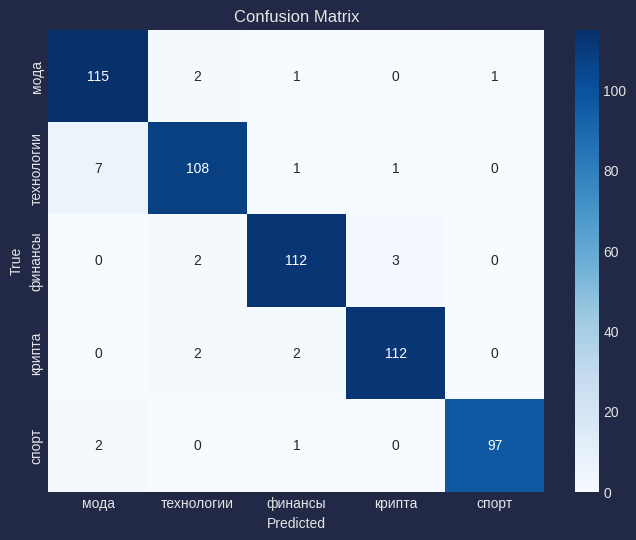

In [500]:
mybert_unfreeze.eval()
all_preds = []
all_labels = []
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

with torch.no_grad():
    for batch in valid_loader:
        # ✅ Простая проверка
        if isinstance(batch, dict):
            # batch = {'input_ids': ..., 'attention_mask': ..., 'labels': ...}
            inputs = {k: v.to(net_config.device) for k, v in batch.items() if k != 'labels'}
            y = batch['labels'].to(net_config.device)
        else:
            # batch = [inputs_dict, labels]
            inputs = batch[0]
            if isinstance(inputs, dict):
                inputs = {k: v.to(net_config.device) for k, v in inputs.items()}
            else:
                inputs = inputs.to(net_config.device)
            y = batch[1].to(net_config.device)
        
        outputs = mybert_unfreeze(**inputs)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# МЕТРИКИ
accuracy = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Macro: {f1_macro:.4f}")

# CLASSIFICATION REPORT
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# CONFUSION MATRIX
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Text(0.5, 1.0, 'F1')

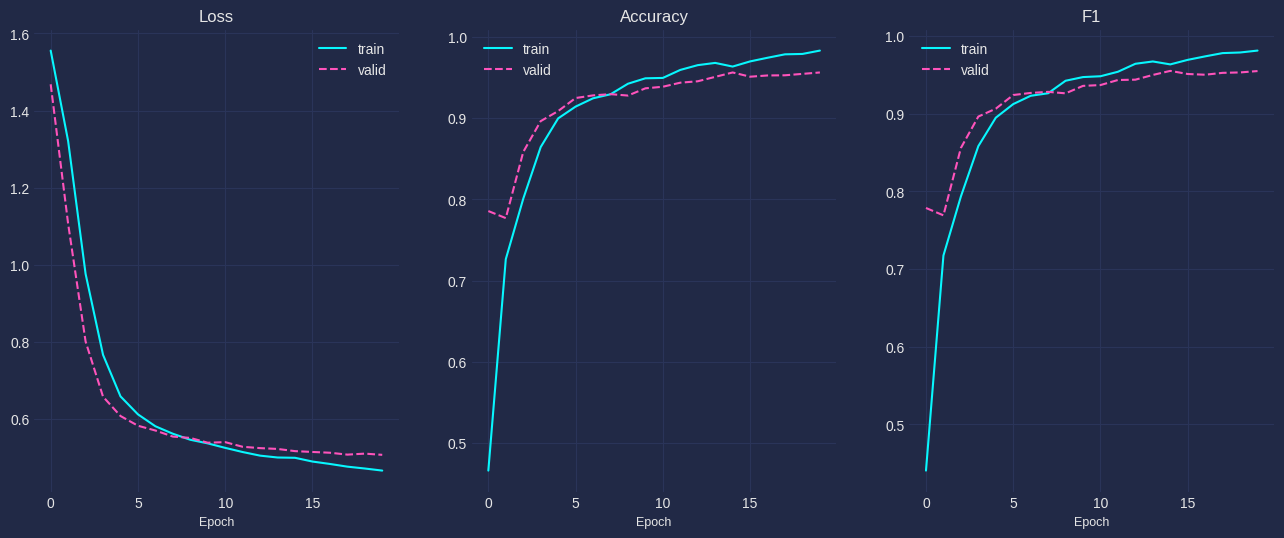

In [501]:
result_all['bert_unfreeze_valid'] = results_unfreeze
fig = plt.figure(figsize=(16, 6))
ax1 = plt.subplot2grid((1,3), (0,0))
ax1.plot(result_all['bert_unfreeze_valid']['train_loss'], label='train')
ax1.plot(result_all['bert_unfreeze_valid']['val_loss'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Loss')

ax1 = plt.subplot2grid((1,3), (0,1))
ax1.plot(result_all['bert_unfreeze_valid']['train_acc'], label='train')
ax1.plot(result_all['bert_unfreeze_valid']['val_acc'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'Accuracy')

ax1 = plt.subplot2grid((1,3), (0,2))
ax1.plot(result_all['bert_unfreeze_valid']['train_f1'], label='train')
ax1.plot(result_all['bert_unfreeze_valid']['val_f1'], linestyle='--', label='valid')
ax1.set_xlabel('Epoch', fontsize=9)
ax1.legend()
ax1.set_title(f'F1')

In [502]:
save_path = 'models/rubert_tiny_tg'
os.makedirs(save_path, exist_ok=True)

# 1. Сохраняем веса всей вашей кастомной модели
torch.save(mybert_unfreeze.state_dict(), os.path.join(save_path, 'model_tg_weights.pt'))

# 2. Сохраняем токенизатор (он точно умеет save_pretrained)
tokenizer.save_pretrained(save_path)

# 3. (Опционально) Сохраняем конфиг базовой модели, если он нужен
# mybert_unfreeze.bert.config.save_pretrained(save_path) 

print("Веса и токенизатор сохранены!")


Веса и токенизатор сохранены!


In [503]:
# 1. Само сообщение, которое хотим проверить
text_to_check = "Доллар имеет тенденцию к снижению на горизонте года Доллар имеет тенденцию к снижению на горизонте года"

# 2. Подготовка данных (Токенизация)
# Важно: используйте тот же токенизатор, на котором обучались
inputs = tokenizer(
    text_to_check, 
    return_tensors="pt", 
    padding=True, 
    truncation=True, 
    max_length=128
)

# Переносим на то же устройство, где модель (например, cpu или cuda)
device = next(mybert_freeze.parameters()).device
inputs = {k: v.to(device) for k, v in inputs.items()}

# 3. Инференс
target_names = {v: k for k, v in mapping.items()} 

mybert_freeze.eval()
with torch.no_grad():
    # Используем ** для распаковки словаря inputs в forward(input_ids, attention_mask)
    outputs = mybert_freeze(**inputs) 
    
    probs = torch.nn.functional.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    confidence = torch.max(probs).item()

# 4. Красивый вывод
category = target_names[pred_idx]

print(f"Текст: {text_to_check}")
print(f"Результат классификации: {category.upper()}")
print(f"Уверенность: {confidence:.2%}")


Текст: Доллар имеет тенденцию к снижению на горизонте года Доллар имеет тенденцию к снижению на горизонте года
Результат классификации: ФИНАНСЫ
Уверенность: 62.16%


In [504]:
import torch
import json
import os

save_path = 'models/rubert_tiny_tg'
os.makedirs(save_path, exist_ok=True)

# 1. Веса модели
torch.save(mybert_unfreeze.state_dict(), os.path.join(save_path, 'model_tg_weights.pt'))

# 2. Токенизатор
tokenizer.save_pretrained(save_path)

# 3. Конфиг для воссоздания архитектуры (важно!)
model_config = {
    'num_labels': 5,
    'model_name': 'cointegrated/rubert-tiny2',
    'hidden_size': 312,  # Можно взять из mybert_unfreeze.bert.config.hidden_size
}
with open(os.path.join(save_path, 'model_config.json'), 'w', encoding='utf-8') as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)

# 4. Маппинг классов (обязательно для продакшена)
class_mapping = {
    "0": "мода",
    "1": "технологии",
    "2": "финансы",
    "3": "крипта",
    "4": "спорт"
}
with open(os.path.join(save_path, 'class_mapping.json'), 'w', encoding='utf-8') as f:
    json.dump(class_mapping, f, ensure_ascii=False, indent=2)

print("✅ Все артефакты для деплоя сохранены!")

✅ Все артефакты для деплоя сохранены!


Accuracy: 0.9561 (95.61%)
F1 Macro: 0.9568
              precision    recall  f1-score   support

        мода     0.9274    0.9664    0.9465       119
  технологии     0.9474    0.9231    0.9351       117
     финансы     0.9573    0.9573    0.9573       117
      крипта     0.9655    0.9655    0.9655       116
       спорт     0.9898    0.9700    0.9798       100

    accuracy                         0.9561       569
   macro avg     0.9575    0.9564    0.9568       569
weighted avg     0.9564    0.9561    0.9561       569



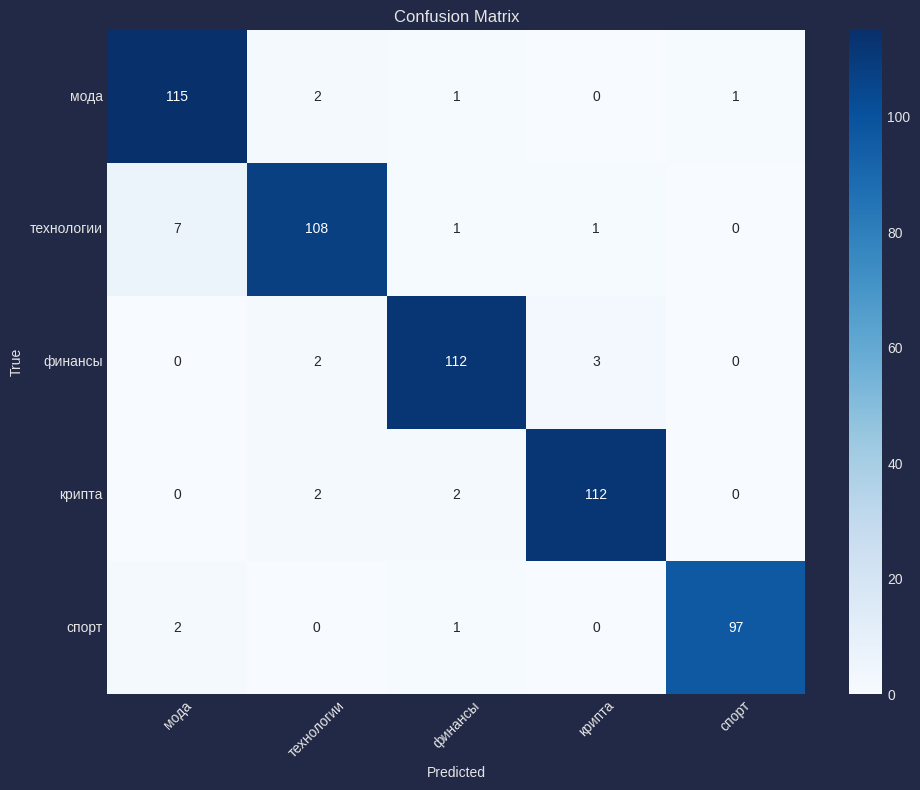


ВСЕГО ОШИБОК: 25 из 569 (4.39%)


📋 ПЕРВЫЕ 20 ОШИБОК:

────────────────────────────────────────────────────────────────────────────────
№ 3 | True: финансы         | Pred: технологии     
────────────────────────────────────────────────────────────────────────────────
Текст: Кардиган очень коварен в стилизации, поэтому его незаслужено считают одеждой для старых тетенек, не смыслящих в моде. Для вашего вдохновения и идей привела примеры, красивой стилизации кардигана🪄Lamoda Brusnika

────────────────────────────────────────────────────────────────────────────────
№ 4 | True: спорт           | Pred: мода           
────────────────────────────────────────────────────────────────────────────────
Текст: Трикотажные костюмы часто ассоциируются с брюками, а как по мне, с юбкой они смотрятся не менее классно. Я бы посоветовала брать юбку длины миди или макси, тогда эффект будет точно «вау». Выбираем более плотный трикотаж он смотрится гораздо интересне...

───────────────────────────────────

In [505]:
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Получи исходные тексты из DataFrame (замени df_valid на свою переменную)
# Если валидация — это срез df:
valid_texts = df['content'].tolist()  # или 'text', 'post' — твоя колонка

mybert_unfreeze.eval()
all_preds = []
all_labels = []
all_texts = []
all_indices = []  # ✅ Сохраняем индексы
labels = ['мода', 'технологии', 'финансы', 'крипта', 'спорт'] 

with torch.no_grad():
    for batch_idx, batch in enumerate(valid_loader):
        # Обработка batch (как у тебя)
        if isinstance(batch, dict):
            inputs = {k: v.to(net_config.device) for k, v in batch.items() if k != 'labels'}
            y = batch['labels'].to(net_config.device)
        elif isinstance(batch, (list, tuple)) and len(batch) == 3:
            inputs = {'input_ids': batch[0].to(net_config.device), 'attention_mask': batch[1].to(net_config.device)}
            y = batch[2].to(net_config.device)
        elif isinstance(batch, (list, tuple)) and len(batch) == 2:
            if isinstance(batch[0], dict):
                inputs = {k: v.to(net_config.device) for k, v in batch[0].items()}
            elif isinstance(batch[0], (tuple, list)):
                inputs = {'input_ids': batch[0][0].to(net_config.device), 'attention_mask': batch[0][1].to(net_config.device)}
            else:
                inputs = {'input_ids': batch[0].to(net_config.device)}
            y = batch[1].to(net_config.device)
        else:
            raise ValueError(f"Неизвестный формат batch: {type(batch)}")
        
        outputs = mybert_unfreeze(**inputs)
        preds = torch.argmax(outputs, dim=1)
        
        # ✅ Сохраняем предсказания
        all_preds.extend(preds.cpu().numpy().astype(int).tolist())
        all_labels.extend(y.cpu().numpy().astype(int).tolist())
        
        # ✅ Получаем тексты по индексам
        batch_start = batch_idx * valid_loader.batch_size
        batch_end = batch_start + len(y)
        batch_texts = valid_texts[batch_start:batch_end]
        all_texts.extend(batch_texts)
        
        # ✅ Сохраняем индексы
        batch_indices = list(range(batch_start, batch_end))
        all_indices.extend(batch_indices)

# ==================== МЕТРИКИ ====================
accuracy = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Macro: {f1_macro:.4f}")
print(classification_report(all_labels, all_preds, digits=4, target_names=labels))

# ==================== CONFUSION MATRIX ====================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.xticks(rotation=45); plt.yticks(rotation=0); plt.tight_layout()
plt.show()

# ==================== НЕВЕРНЫЕ ПРЕДСКАЗАНИЯ ====================
incorrect_indices = [i for i, (t, p) in enumerate(zip(all_labels, all_preds)) if t != p]

print(f"\n{'='*80}")
print(f"ВСЕГО ОШИБОК: {len(incorrect_indices)} из {len(all_labels)} ({len(incorrect_indices)/len(all_labels)*100:.2f}%)")
print(f"{'='*80}\n")

if len(incorrect_indices) > 0:
    errors_df = pd.DataFrame({
        'dataset_index': [all_indices[i] for i in incorrect_indices],  # ✅ Индекс в df
        'text': [all_texts[i] for i in incorrect_indices],             # ✅ Теперь с текстом!
        'true_label': [labels[all_labels[i]] for i in incorrect_indices],
        'pred_label': [labels[all_preds[i]] for i in incorrect_indices],
        'true_id': [all_labels[i] for i in incorrect_indices],
        'pred_id': [all_preds[i] for i in incorrect_indices]
    })

    # Показываем ошибки
    print(f"\n📋 ПЕРВЫЕ {min(20, len(errors_df))} ОШИБОК:\n")
    for idx, row in errors_df.head(20).iterrows():
        print(f"{'─'*80}")
        print(f"№ {row['dataset_index']} | True: {row['true_label']:15} | Pred: {row['pred_label']:15}")
        print(f"{'─'*80}")
        text_preview = row['text'][:250] if pd.notna(row['text']) else "[ПУСТО]"
        print(f"Текст: {text_preview}{'...' if len(str(row['text'])) > 250 else ''}")
        print()

    # Статистика ошибок
    print(f"\n{'='*80}\n📊 ОШИБКИ ПО КЛАССАМ:\n{'='*80}\n")
    for true_class in range(len(labels)):
        class_errors = errors_df[errors_df['true_id'] == true_class]
        if len(class_errors) > 0:
            print(f"\n📌 {labels[true_class].upper()} (ошибок: {len(class_errors)}):")
            for pred_label, count in class_errors['pred_label'].value_counts().items():
                print(f"   → {pred_label}: {count} ({count/len(class_errors)*100:.1f}%)")

    # Сохранение
    errors_df.to_csv('incorrect_predictions.csv', index=False, encoding='utf-8-sig')
    print(f"\n✅ Ошибки сохранены в: incorrect_predictions.csv")